# P300 EEG -> Adaptive-LIF SNN classifier (block-averaged)



In [1]:
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from scipy.io import loadmat
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    balanced_accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


# CONFIG


DATA_ROOT = Path("../data")     # same as  original notebook — change only if needed
SUBJECT = "SBJ01"
SESSIONS = None                 # None = auto-discover and use ALL sessions for this subject

FS = 250
LOWCUT = 0.1
HIGHCUT = 20.0

N_OBJECTS = 8            # objects in the P300 speller matrix (adjust if different)
EPOCHS_PER_BLOCK = 80    # 10 runs x 8 objects, same as your original BLOCK_SIZE

N_HIDDEN = 64
DROPOUT = 0.3
BATCH_SIZE = 32
N_EPOCHS = 100
LR = 3e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 20
DOWNSAMPLE_FACTOR = 2    # 350 -> 175 timesteps: shortens BPTT and roughly halves training time
LOGIT_SCALE_INIT = 10.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### 1. Data loading — ALL blocks, ALL sessions for the subject

Loads every session on disk for the subject (not just one block). Also keeps `events` (which object was flashed on each epoch) and a block-group id per epoch — both needed for the block-averaging step below.

In [2]:
def discover_sessions(subject_dir):
    return sorted(p for p in subject_dir.glob("S*") if (p / "Train").exists())


def load_session_train(session_dir):
    train_dir = session_dir / "Train"

    mat = loadmat(train_dir / "trainData.mat")
    data_vars = {k: v for k, v in mat.items() if not k.startswith("__")}
    eeg = list(data_vars.values())[0]                      # (channels, samples, epochs)
    X = np.transpose(eeg, (2, 0, 1)).astype(np.float32)     # (epochs, channels, samples)

    targets = np.loadtxt(train_dir / "trainTargets.txt", dtype=int).flatten()
    events = np.loadtxt(train_dir / "trainEvents.txt", dtype=int).flatten()

    block_ids = np.arange(len(targets)) // EPOCHS_PER_BLOCK
    return X, targets, events, block_ids


def load_subject_epochs(data_root, subject, sessions=None):
    subject_dir = data_root / subject
    session_dirs = (
        discover_sessions(subject_dir) if sessions is None
        else [subject_dir / s for s in sessions]
    )

    all_X, all_y, all_events, all_groups = [], [], [], []
    for session_dir in session_dirs:
        X, y, events, block_ids = load_session_train(session_dir)
        groups = [f"{session_dir.name}_B{b}" for b in block_ids]
        all_X.append(X)
        all_y.append(y)
        all_events.append(events)
        all_groups.extend(groups)
        print(f"  {session_dir.name}: {X.shape[0]} epochs "
              f"({int((y == 1).sum())} target / {int((y == 0).sum())} non-target)")

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)
    events = np.concatenate(all_events, axis=0)
    groups = np.array(all_groups)
    return X, y, events, groups


print(f"Loading all sessions for {SUBJECT} ...")
X_raw, y_all, events_all, groups_all = load_subject_epochs(DATA_ROOT, SUBJECT, SESSIONS)
print(f"\nTotal epochs: {X_raw.shape[0]}  "
      f"(target={int((y_all == 1).sum())}, non-target={int((y_all == 0).sum())})")

Loading all sessions for SBJ01 ...
  S01: 1600 epochs (200 target / 1400 non-target)
  S02: 1600 epochs (200 target / 1400 non-target)
  S03: 1600 epochs (200 target / 1400 non-target)
  S04: 1600 epochs (200 target / 1400 non-target)
  S05: 1600 epochs (200 target / 1400 non-target)
  S06: 1600 epochs (200 target / 1400 non-target)
  S07: 1600 epochs (200 target / 1400 non-target)

Total epochs: 11200  (target=1400, non-target=9800)


### 2. Preprocessing

Same band-pass filter, baseline correction (-200 to 0 ms), and per-channel z-score normalization as your original Phase 1.

In [3]:
def preprocess_eeg(X, fs=250, lowcut=0.1, highcut=20.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    X_filt = filtfilt(b, a, X, axis=-1)

    baseline_samples = int(0.2 * fs)  # epoch starts at -200 ms
    baseline_mean = X_filt[:, :, :baseline_samples].mean(axis=2, keepdims=True)
    X_bc = X_filt - baseline_mean

    ch_mean = X_bc.mean(axis=2, keepdims=True)
    ch_std = X_bc.std(axis=2, keepdims=True)
    X_norm = (X_bc - ch_mean) / (ch_std + 1e-8)
    return X_norm.astype(np.float32)


print("Preprocessing (bandpass + baseline correction + z-score)...")
X_prep = preprocess_eeg(X_raw, FS, LOWCUT, HIGHCUT)
print("Preprocessed shape:", X_prep.shape)

Preprocessing (bandpass + baseline correction + z-score)...
Preprocessed shape: (11200, 8, 350)


In [4]:
X_prep

array([[[ 0.9828572 ,  0.80434054,  0.6188117 , ..., -0.06945639,
         -0.1151591 , -0.17000216],
        [ 0.91726434,  0.52241486,  0.16089903, ...,  0.16288027,
          0.15749861,  0.1265184 ],
        [ 1.0429425 ,  0.5815481 ,  0.16093495, ...,  0.05829445,
          0.03592201, -0.02800204],
        ...,
        [ 0.83114904,  0.62818366,  0.43826473, ..., -0.11606465,
         -0.13799484, -0.17142577],
        [ 0.7568712 ,  0.37178254,  0.03228284, ...,  0.05765662,
          0.02961772, -0.01834695],
        [ 0.6372831 ,  0.29059717, -0.01525554, ...,  0.13816267,
          0.10667614,  0.06388666]],

       [[-1.5891676 , -1.2381597 , -0.8993428 , ..., -1.2056328 ,
         -0.89908737, -0.53930616],
        [-1.3585681 , -0.9731587 , -0.6039601 , ..., -1.3325131 ,
         -1.094039  , -0.8176039 ],
        [-1.2229224 , -0.8346209 , -0.46374607, ..., -0.98310465,
         -0.779371  , -0.54469156],
        ...,
        [-1.172652  , -0.86728084, -0.58049583, ..., -

### 3. Signal diagnostic — is there separable signal, and does averaging help?

Two cheap checks (seconds, not hours) before spending time training the SNN:
1. A trivial linear baseline (LDA / logistic regression on mean P300-window amplitude, cross-validated) on single trials — this is what first revealed the SNN was underperforming a two-line linear model on the same data.
2. The same check after collapsing repeated flashes of the same object within a block into one averaged epoch.

If both numbers come back near 0.5, the problem is upstream of any model (channels, timing, artifacts) and no amount of SNN tuning will fix it. If single-trial is clearly above 0.5 but the SNN still lands near 0.5 later in this notebook, that's a pipeline gap, not a data gap — worth revisiting the encoding step.

In [5]:
t_axis = np.arange(X_prep.shape[2]) / FS - 0.2   # epoch starts at -200 ms
p300_mask = (t_axis >= 0.25) & (t_axis <= 0.6)

# ---- 1. Single-trial linear baseline ----
feat_single = X_prep[:, :, p300_mask].mean(axis=2)   # (epochs, channels)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_lda_single = cross_val_score(LinearDiscriminantAnalysis(), feat_single, y_all, cv=cv, scoring="roc_auc")
auc_lr_single = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=1000), feat_single, y_all, cv=cv, scoring="roc_auc")

print("SINGLE-TRIAL linear baselines (cross-val ROC-AUC):")
print(f"  LDA:                 {auc_lda_single.mean():.3f} +/- {auc_lda_single.std():.3f}")
print(f"  Logistic Regression:  {auc_lr_single.mean():.3f} +/- {auc_lr_single.std():.3f}")
print("  ~0.5 => no separable signal in this window/preprocessing; >0.6 => signal is present")

SINGLE-TRIAL linear baselines (cross-val ROC-AUC):
  LDA:                 0.571 +/- 0.015
  Logistic Regression:  0.572 +/- 0.015
  ~0.5 => no separable signal in this window/preprocessing; >0.6 => signal is present


### 4. Block averaging

Collapses the repeated flashes of each object within a block into one averaged epoch — standard P300-speller SNR-boosting practice. This is the dataset the main path trains on below.

In [6]:
def build_block_averaged_dataset(X, y, events, groups):
    unique_groups = np.unique(groups)
    avg_X, avg_y, avg_group = [], [], []
    for g in unique_groups:
        block_mask = groups == g
        block_X = X[block_mask]
        block_y = y[block_mask]
        block_events = events[block_mask]
        for obj in np.unique(block_events):
            obj_mask = block_events == obj
            avg_X.append(block_X[obj_mask].mean(axis=0))
            avg_y.append(int(block_y[obj_mask][0]))   # constant within (block, object) group
            avg_group.append(g)
    return (np.array(avg_X, dtype=np.float32),
            np.array(avg_y, dtype=np.int64),
            np.array(avg_group))


X_avg, y_avg, groups_avg = build_block_averaged_dataset(X_prep, y_all, events_all, groups_all)
print(f"Block-averaged dataset: {X_avg.shape[0]} examples "
      f"({int(y_avg.sum())} target / {int((y_avg == 0).sum())} non-target), shape {X_avg.shape}")

# same diagnostic, on the averaged epochs, to confirm the SNR boost before training
feat_avg = X_avg[:, :, p300_mask].mean(axis=2)
cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_lda_avg = cross_val_score(LinearDiscriminantAnalysis(), feat_avg, y_avg, cv=cv2, scoring="roc_auc")
auc_lr_avg = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=1000), feat_avg, y_avg, cv=cv2, scoring="roc_auc")
print("\nBLOCK-AVERAGED linear baselines (cross-val ROC-AUC):")
print(f"  LDA:                 {auc_lda_avg.mean():.3f} +/- {auc_lda_avg.std():.3f}")
print(f"  Logistic Regression:  {auc_lr_avg.mean():.3f} +/- {auc_lr_avg.std():.3f}")

Block-averaged dataset: 1120 examples (140 target / 980 non-target), shape (1120, 8, 350)

BLOCK-AVERAGED linear baselines (cross-val ROC-AUC):
  LDA:                 0.713 +/- 0.060
  Logistic Regression:  0.676 +/- 0.049


In [7]:
feat_avg

array([[-0.01214028, -0.06494951, -0.05878456, ..., -0.05195783,
        -0.15416402, -0.10700306],
       [-0.25329253, -0.3827428 , -0.2849809 , ..., -0.18542452,
        -0.25310254, -0.21141429],
       [-0.15019496, -0.15849032, -0.12524246, ..., -0.07098908,
        -0.0458279 , -0.01645504],
       ...,
       [-0.1487825 , -0.09642071, -0.11200258, ..., -0.2287935 ,
        -0.21057251, -0.26400712],
       [ 0.24968292,  0.11168292,  0.09502906, ...,  0.14305624,
         0.06716762,  0.07600812],
       [-0.04253001, -0.07577906, -0.09728551, ..., -0.02876213,
         0.01754592,  0.00329047]], dtype=float32)

In [8]:
X_avg

array([[[-0.02913485, -0.00824891,  0.00579379, ..., -0.16250107,
         -0.09707685, -0.02361843],
        [-0.42545477, -0.35445195, -0.28762287, ..., -0.3074438 ,
         -0.23074341, -0.13899949],
        [-0.59756577, -0.60328513, -0.60176325, ..., -0.20965576,
         -0.12503797, -0.02163892],
        ...,
        [-0.12537244, -0.00748204,  0.10460208, ..., -0.28705204,
         -0.18059587, -0.06350528],
        [-0.38199455, -0.31287208, -0.2452353 , ..., -0.23855722,
         -0.14044145, -0.02845024],
        [-0.2259512 , -0.10081013,  0.01961899, ..., -0.33931786,
         -0.22934751, -0.10723462]],

       [[-0.27435184, -0.24150245, -0.20859042, ..., -0.26444203,
         -0.28476295, -0.29183984],
        [-0.45332852, -0.43231788, -0.4111065 , ..., -0.11930501,
         -0.19976045, -0.27194855],
        [-0.6048087 , -0.52300775, -0.44319725, ..., -0.13522895,
         -0.26210886, -0.39153162],
        ...,
        [-0.3622473 , -0.26619858, -0.17476606, ..., -

### 5. SNN model and training loop

Same Adaptive-LIF dynamics as before (membrane leak `beta`, adaptation `rho`, surrogate-gradient spike function). Readout is the mean spike rate through a learnable scale, not a raw spike count. `train_snn(...)` bundles the split / train / evaluate loop into one function.

In [9]:
def rate_encode(X, seed=42):
    rng = np.random.default_rng(seed)
    X_min = X.min(axis=2, keepdims=True)
    X_max = X.max(axis=2, keepdims=True)
    X_norm = (X - X_min) / (X_max - X_min + 1e-8)
    spikes = (rng.random(X_norm.shape) < X_norm).astype(np.float32)
    return spikes


def downsample_time(spikes, factor=2):
    T = spikes.shape[2]
    T_trim = T - (T % factor)
    spikes = spikes[:, :, :T_trim]
    return spikes.reshape(spikes.shape[0], spikes.shape[1], -1, factor).max(axis=3)


class SpikeFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, membrane, threshold):
        ctx.save_for_backward(membrane)
        ctx.threshold = threshold
        return (membrane >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        (membrane,) = ctx.saved_tensors
        threshold = ctx.threshold
        grad = 1.0 / (1.0 + torch.abs(membrane - threshold)) ** 2
        return grad_output * grad, None


spike_fn = SpikeFunction.apply


class AdaptiveLIFNet(nn.Module):
    """Hidden layer spikes (genuine SNN dynamics). Output layer is a
    continuous leaky-integrator, NOT a second spiking layer -- see the
    note above this cell for why."""
    def __init__(self, input_size=8, hidden_size=64, output_size=2,
                 beta=0.9, rho=0.95, adapt_strength=0.15,
                 dropout=0.3, threshold=1.0, logit_scale_init=10.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.threshold = threshold
        self.beta = beta
        self.rho = rho
        self.adapt_strength = adapt_strength

        self.fc_in = nn.Linear(input_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
        # scaled down from the raw init value since membrane potentials aren't
        # bounded to [0,1] the way a spike rate is
        self.logit_scale = nn.Parameter(torch.tensor(logit_scale_init * 0.1))

    def forward(self, x):
        batch, _, T = x.shape

        v = torch.zeros(batch, self.hidden_size, device=x.device)
        adapt = torch.zeros(batch, self.hidden_size, device=x.device)
        v_out = torch.zeros(batch, self.output_size, device=x.device)

        hidden_trace, membrane_trace = [], []

        for t in range(T):
            x_t = x[:, :, t]

            current = self.dropout(self.fc_in(x_t))
            v = self.beta * v + current - adapt
            s = spike_fn(v, self.threshold)
            v = v * (1.0 - s)
            adapt = self.rho * adapt + self.adapt_strength * s

            out_current = self.fc_out(s)
            v_out = self.beta * v_out + out_current   # continuous leaky-integrator, no reset/threshold here

            hidden_trace.append(s)
            membrane_trace.append(v_out)

        hidden_trace = torch.stack(hidden_trace, dim=1)
        membrane_trace = torch.stack(membrane_trace, dim=1)     # (batch, T, output_size)

        mean_potential = membrane_trace.mean(dim=1)
        logits = mean_potential * self.logit_scale

        return logits, hidden_trace, membrane_trace


def make_splits(y, groups=None, seed=42):
    """Block-grouped split when `groups` is given (keeps every example from the
    same block together, avoiding block-level leakage across train/val/test).
    Falls back to a plain stratified split if no groups are provided."""
    if groups is None:
        idx = np.arange(len(y))
        train_idx, temp_idx = train_test_split(idx, test_size=0.3, stratify=y, random_state=seed)
        val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=seed)
        return train_idx, val_idx, test_idx

    rng = np.random.default_rng(seed)
    unique_groups = np.unique(groups)
    rng.shuffle(unique_groups)

    n = len(unique_groups)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_groups = set(unique_groups[:n_train])
    val_groups = set(unique_groups[n_train:n_train + n_val])
    test_groups = set(unique_groups[n_train + n_val:])

    train_idx = np.where(np.isin(groups, list(train_groups)))[0]
    val_idx = np.where(np.isin(groups, list(val_groups)))[0]
    test_idx = np.where(np.isin(groups, list(test_groups)))[0]
    return train_idx, val_idx, test_idx


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["train_loss"], label="Training")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(np.array(history["train_acc"]) * 100, label="Training")
    axes[1].plot(np.array(history["val_acc"]) * 100, label="Validation")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def train_snn(spike_data, y, label, groups=None,
              n_epochs=N_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
              hidden=N_HIDDEN, dropout=DROPOUT, logit_scale_init=LOGIT_SCALE_INIT,
              weight_decay=WEIGHT_DECAY, patience=PATIENCE, seed=42):

    torch.manual_seed(seed)
    np.random.seed(seed)

    train_idx, val_idx, test_idx = make_splits(y, groups=groups, seed=seed)
    train_X = torch.tensor(spike_data[train_idx], dtype=torch.float32)
    train_y = torch.tensor(y[train_idx], dtype=torch.long)
    val_X = torch.tensor(spike_data[val_idx], dtype=torch.float32).to(device)
    val_y = torch.tensor(y[val_idx], dtype=torch.long).to(device)
    test_X = torch.tensor(spike_data[test_idx], dtype=torch.float32).to(device)
    test_y = torch.tensor(y[test_idx], dtype=torch.long).to(device)

    print(f"[{label}] Train: {len(train_idx)} (target={(y[train_idx]==1).sum()})  "
          f"Val: {len(val_idx)} (target={(y[val_idx]==1).sum()})  "
          f"Test: {len(test_idx)} (target={(y[test_idx]==1).sum()})")

    model = AdaptiveLIFNet(input_size=8, hidden_size=hidden, output_size=2,
                            dropout=dropout, logit_scale_init=logit_scale_init).to(device)

    n0 = int((train_y == 0).sum()); n1 = int((train_y == 1).sum()); tot = n0 + n1
    class_weights = torch.tensor([tot / (2 * n0), tot / (2 * n1)], dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
    train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=batch_size, shuffle=True)

    best_val_bal_acc = -1.0
    best_state = None
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    print(f"\n[{label}] Training...")
    for epoch in range(n_epochs):
        model.train()
        running_loss, running_correct, running_n = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits, _, _ = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            running_correct += (logits.argmax(1) == yb).sum().item()
            running_n += xb.size(0)

        train_loss = running_loss / running_n
        train_acc = running_correct / running_n

        model.eval()
        with torch.no_grad():
            val_logits, _, _ = model(val_X)
            val_loss = criterion(val_logits, val_y).item()
            val_pred = val_logits.argmax(1)
            val_bal_acc = balanced_accuracy_score(val_y.cpu().numpy(), val_pred.cpu().numpy())
            val_acc = (val_pred == val_y).float().mean().item()

        scheduler.step(val_bal_acc)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)

        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc = val_bal_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.1f}% | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.1f}% BalAcc: {val_bal_acc*100:.1f}%")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1} (best val bal-acc: {best_val_bal_acc*100:.1f}%)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        test_logits, test_hidden, test_membrane = model(test_X)
        test_probs = torch.softmax(test_logits, dim=1)[:, 1]
        test_pred = test_logits.argmax(1)

    true = test_y.cpu().numpy(); pred = test_pred.cpu().numpy(); probs = test_probs.cpu().numpy()

    print(f"\n[{label}] FINAL TEST RESULTS")
    print(classification_report(true, pred, target_names=["Non-target", "Target"], zero_division=0))
    print("Balanced accuracy:", balanced_accuracy_score(true, pred))
    try:
        test_auc = roc_auc_score(true, probs)
        print("ROC-AUC:", test_auc)
    except ValueError as e:
        test_auc = float("nan")
        print("ROC-AUC: n/a (", e, ")")
    print("Confusion matrix:")
    print(confusion_matrix(true, pred))

    return {
        "model": model, "history": history,
        "test_true": true, "test_pred": pred, "test_probs": probs,
        "test_hidden_trace": test_hidden.cpu().numpy(),
        "test_membrane_trace": test_membrane.cpu().numpy(),
        "balanced_accuracy": balanced_accuracy_score(true, pred),
        "roc_auc": test_auc,
    }

## Train and evaluate

Trains and evaluates the SNN on the block-averaged (high-SNR) dataset built above, using the block-grouped split.

In [10]:
spike_avg = rate_encode(X_avg, seed=42)
spike_avg = downsample_time(spike_avg, factor=DOWNSAMPLE_FACTOR)
print("Block-averaged spike train shape:", spike_avg.shape)

results_avg = train_snn(spike_avg, y_avg, label="block-averaged", groups=groups_avg)

Block-averaged spike train shape: (1120, 8, 175)
[block-averaged] Train: 784 (target=98)  Val: 168 (target=21)  Test: 168 (target=21)

[block-averaged] Training...
  Epoch   1/100 | Train Loss: 0.7090 Acc: 76.7% | Val Loss: 0.7392 Acc: 12.5% BalAcc: 50.0%
  Epoch   5/100 | Train Loss: 0.7043 Acc: 28.6% | Val Loss: 0.7176 Acc: 87.5% BalAcc: 50.0%
  Epoch  10/100 | Train Loss: 0.6935 Acc: 67.0% | Val Loss: 0.6909 Acc: 86.3% BalAcc: 49.3%
  Epoch  15/100 | Train Loss: 0.6906 Acc: 82.0% | Val Loss: 0.6907 Acc: 75.0% BalAcc: 55.1%
  Epoch  20/100 | Train Loss: 0.6910 Acc: 66.6% | Val Loss: 0.6905 Acc: 70.2% BalAcc: 56.5%
  Epoch  25/100 | Train Loss: 0.6913 Acc: 64.5% | Val Loss: 0.6927 Acc: 82.7% BalAcc: 49.3%
  Epoch  30/100 | Train Loss: 0.6905 Acc: 64.2% | Val Loss: 0.6919 Acc: 77.4% BalAcc: 54.4%
  Epoch  35/100 | Train Loss: 0.6896 Acc: 75.4% | Val Loss: 0.6923 Acc: 81.0% BalAcc: 56.5%
  Epoch  40/100 | Train Loss: 0.6888 Acc: 78.2% | Val Loss: 0.6924 Acc: 83.3% BalAcc: 53.7%
  Early 

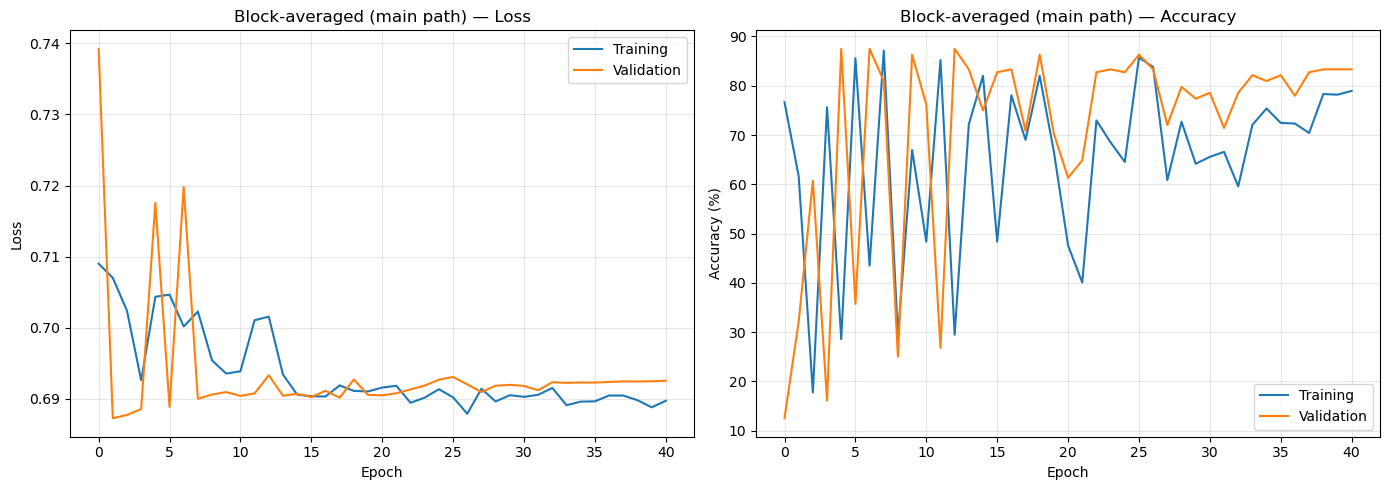

In [11]:
plot_history(results_avg["history"], title="Block-averaged (main path)")

### Save trajectories for the DDM stage

From the block-averaged model's held-out test set. Since each example here is already an averaged evidence signal across repeated flashes, this trajectory captures the SNN's within-epoch temporal dynamics on top of the across-repeat averaging.

In [13]:
print("Hidden spike trajectory:    ", results_avg["test_hidden_trace"].shape)
print("Output membrane trajectory: ", results_avg["test_membrane_trace"].shape)
print("\nNext stage: output membrane trajectory -> evidence trajectory -> DDM (v, a, t0)")


Hidden spike trajectory:     (168, 175, 64)
Output membrane trajectory:  (168, 175, 2)

Next stage: output membrane trajectory -> evidence trajectory -> DDM (v, a, t0)


In [14]:
# ============================================================
# COMPARISON OF SNN HIDDEN-LAYER ARCHITECTURES
# ============================================================
#
# Models:
#   SNN-32:       8 -> 32 LIF -> 2
#   SNN-64:       8 -> 64 LIF -> 2
#   SNN-128:      8 -> 128 LIF -> 2
#   SNN-3Layer:   8 -> 32 LIF -> 64 LIF -> 128 LIF -> 2
#
# Uses the SAME block-averaged spike data and SAME
# group-based train/validation/test split for fair comparison.
# ============================================================

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. ADAPTIVE-LIF SPIKING NEURON
# ============================================================

class SpikeFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, membrane, threshold):
        ctx.save_for_backward(membrane)
        ctx.threshold = threshold

        return (membrane >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        (membrane,) = ctx.saved_tensors
        threshold = ctx.threshold

        # Surrogate gradient
        grad = 1.0 / (1.0 + torch.abs(membrane - threshold)) ** 2

        return grad_output * grad, None


spike_fn = SpikeFunction.apply


# ============================================================
# 2. MULTI-LAYER ADAPTIVE-LIF SNN
# ============================================================

class MultiLayerAdaptiveLIFNet(nn.Module):

    def __init__(
        self,
        input_size=8,
        hidden_sizes=(64,),
        output_size=2,
        beta=0.9,
        rho=0.95,
        adapt_strength=0.15,
        dropout=0.3,
        threshold=1.0,
        logit_scale_init=10.0
    ):

        super().__init__()

        self.hidden_sizes = list(hidden_sizes)
        self.beta = beta
        self.rho = rho
        self.adapt_strength = adapt_strength
        self.threshold = threshold

        # --------------------------------------------
        # Input -> first hidden layer
        # --------------------------------------------

        layers = []

        in_features = input_size

        for hidden_size in self.hidden_sizes:

            layers.append(
                nn.Linear(in_features, hidden_size)
            )

            in_features = hidden_size

        self.fc_layers = nn.ModuleList(layers)

        # Dropout between layers
        self.dropout = nn.Dropout(dropout)

        # Final readout
        self.fc_out = nn.Linear(
            self.hidden_sizes[-1],
            output_size
        )

        # Learnable output scale
        self.logit_scale = nn.Parameter(
            torch.tensor(logit_scale_init * 0.1)
        )


    def forward(self, x):

        batch, _, T = x.shape

        # ------------------------------------------------
        # Membrane potentials for every hidden layer
        # ------------------------------------------------

        membranes = []

        adaptations = []

        for hidden_size in self.hidden_sizes:

            membranes.append(
                torch.zeros(
                    batch,
                    hidden_size,
                    device=x.device
                )
            )

            adaptations.append(
                torch.zeros(
                    batch,
                    hidden_size,
                    device=x.device
                )
            )

        # Output membrane
        v_out = torch.zeros(
            batch,
            self.fc_out.out_features,
            device=x.device
        )

        hidden_spikes = []

        output_trace = []


        # ====================================================
        # TIME LOOP
        # ====================================================

        for t in range(T):

            # EEG spike input at time t
            current = x[:, :, t]

            layer_spikes = []

            # ------------------------------------------------
            # Pass through every Adaptive-LIF hidden layer
            # ------------------------------------------------

            for i, fc in enumerate(self.fc_layers):

                current = fc(current)

                current = self.dropout(current)

                # Adaptive LIF dynamics
                membranes[i] = (
                    self.beta * membranes[i]
                    + current
                    - adaptations[i]
                )

                # Generate spike
                s = spike_fn(
                    membranes[i],
                    self.threshold
                )

                # Reset after spike
                membranes[i] = (
                    membranes[i] * (1.0 - s)
                )

                # Adaptation
                adaptations[i] = (
                    self.rho * adaptations[i]
                    + self.adapt_strength * s
                )

                # Spike becomes input to next layer
                current = s

                layer_spikes.append(s)

            # ------------------------------------------------
            # Continuous output readout
            # ------------------------------------------------

            out_current = self.fc_out(current)

            v_out = (
                self.beta * v_out
                + out_current
            )

            hidden_spikes.append(layer_spikes)
            output_trace.append(v_out)


        # ====================================================
        # ORGANIZE OUTPUT
        # ====================================================

        output_trace = torch.stack(
            output_trace,
            dim=1
        )

        # Mean output membrane over time
        mean_output = output_trace.mean(dim=1)

        # Classification logits
        logits = (
            mean_output
            * self.logit_scale
        )

        return logits, hidden_spikes, output_trace


# ============================================================
# 3. TRAINING FUNCTION
# ============================================================

def train_and_evaluate_snn(
    spike_data,
    y,
    groups,
    model_name,
    hidden_sizes,
    n_epochs=100,
    lr=3e-3,
    batch_size=32,
    dropout=0.3,
    weight_decay=1e-4,
    patience=20,
    seed=42
):

    print("\n" + "=" * 70)
    print(model_name)
    print("Architecture:", [8] + list(hidden_sizes) + [2])
    print("=" * 70)

    # Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)

    # --------------------------------------------------------
    # SAME GROUP SPLIT
    # --------------------------------------------------------

    train_idx, val_idx, test_idx = make_splits(
        y,
        groups=groups,
        seed=seed
    )

    train_X = torch.tensor(
        spike_data[train_idx],
        dtype=torch.float32
    )

    train_y = torch.tensor(
        y[train_idx],
        dtype=torch.long
    )

    val_X = torch.tensor(
        spike_data[val_idx],
        dtype=torch.float32
    ).to(device)

    val_y = torch.tensor(
        y[val_idx],
        dtype=torch.long
    ).to(device)

    test_X = torch.tensor(
        spike_data[test_idx],
        dtype=torch.float32
    ).to(device)

    test_y = torch.tensor(
        y[test_idx],
        dtype=torch.long
    ).to(device)


    print(
        f"Train: {len(train_idx)} | "
        f"Val: {len(val_idx)} | "
        f"Test: {len(test_idx)}"
    )


    # ========================================================
    # MODEL
    # ========================================================

    model = MultiLayerAdaptiveLIFNet(
        input_size=8,
        hidden_sizes=hidden_sizes,
        output_size=2,
        beta=0.9,
        rho=0.95,
        adapt_strength=0.15,
        dropout=dropout,
        threshold=1.0,
        logit_scale_init=10.0
    ).to(device)


    # ========================================================
    # CLASS WEIGHTS
    # ========================================================

    n0 = int((train_y == 0).sum())
    n1 = int((train_y == 1).sum())

    total = n0 + n1

    class_weights = torch.tensor(
        [
            total / (2 * n0),
            total / (2 * n1)
        ],
        dtype=torch.float32,
        device=device
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )


    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5
    )


    train_loader = DataLoader(
        TensorDataset(train_X, train_y),
        batch_size=batch_size,
        shuffle=True
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    best_val_bal_acc = -1

    best_state = None

    patience_counter = 0


    # ========================================================
    # TRAINING
    # ========================================================

    for epoch in range(n_epochs):

        model.train()

        running_loss = 0
        running_correct = 0
        running_n = 0


        for xb, yb in train_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits, _, _ = model(xb)

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()


            running_loss += (
                loss.item()
                * xb.size(0)
            )

            running_correct += (
                (logits.argmax(1) == yb)
                .sum()
                .item()
            )

            running_n += xb.size(0)


        train_loss = (
            running_loss / running_n
        )

        train_acc = (
            running_correct / running_n
        )


        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        with torch.no_grad():

            val_logits, _, _ = model(val_X)

            val_loss = criterion(
                val_logits,
                val_y
            ).item()

            val_pred = val_logits.argmax(1)

            val_bal_acc = balanced_accuracy_score(
                val_y.cpu().numpy(),
                val_pred.cpu().numpy()
            )


        scheduler.step(val_bal_acc)


        # ====================================================
        # SAVE BEST MODEL
        # ====================================================

        if val_bal_acc > best_val_bal_acc:

            best_val_bal_acc = val_bal_acc

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            patience_counter = 0

        else:

            patience_counter += 1


        if epoch == 0 or (epoch + 1) % 5 == 0:

            print(
                f"Epoch {epoch+1:3d}/{n_epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc*100:.1f}% | "
                f"Val BalAcc: {val_bal_acc*100:.1f}%"
            )


        if patience_counter >= patience:

            print(
                f"Early stopping at epoch {epoch+1} | "
                f"Best Val BalAcc: "
                f"{best_val_bal_acc*100:.1f}%"
            )

            break


    # ========================================================
    # LOAD BEST MODEL
    # ========================================================

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    model.eval()


    # ========================================================
    # TEST
    # ========================================================

    with torch.no_grad():

        test_logits, _, _ = model(test_X)

        test_probs = torch.softmax(
            test_logits,
            dim=1
        )[:, 1]

        test_pred = test_logits.argmax(1)


    true = test_y.cpu().numpy()

    pred = test_pred.cpu().numpy()

    probs = test_probs.cpu().numpy()


    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(
        true,
        pred
    )

    balanced_acc = balanced_accuracy_score(
        true,
        pred
    )

    sensitivity = recall_score(
        true,
        pred,
        pos_label=1,
        zero_division=0
    )

    specificity = recall_score(
        true,
        pred,
        pos_label=0,
        zero_division=0
    )

    f1 = f1_score(
        true,
        pred,
        pos_label=1,
        zero_division=0
    )

    auc = roc_auc_score(
        true,
        probs
    )


    print("\nFINAL TEST RESULTS")

    print(
        f"Accuracy:           {accuracy:.4f}"
    )

    print(
        f"Balanced Accuracy:  {balanced_acc:.4f}"
    )

    print(
        f"Sensitivity:        {sensitivity:.4f}"
    )

    print(
        f"Specificity:        {specificity:.4f}"
    )

    print(
        f"F1 Score:           {f1:.4f}"
    )

    print(
        f"ROC-AUC:            {auc:.4f}"
    )

    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            true,
            pred
        )
    )


    return {
        "method": model_name,
        "hidden_sizes": hidden_sizes,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "roc_auc": auc,
        "model": model
    }


# ============================================================
# 4. RUN ALL ARCHITECTURES
# ============================================================

architectures = {

    "SNN - 32 hidden":
        (32,),

    "SNN - 64 hidden":
        (64,),

    "SNN - 128 hidden":
        (128,),

    "SNN - 3 hidden layers (32-64-128)":
        (32, 64, 128)
}


results = []


for name, architecture in architectures.items():

    result = train_and_evaluate_snn(
        spike_data=spike_avg,
        y=y_avg,
        groups=groups_avg,
        model_name=name,
        hidden_sizes=architecture,
        n_epochs=100,
        lr=3e-3,
        batch_size=32,
        dropout=0.3,
        weight_decay=1e-4,
        patience=20,
        seed=42
    )

    results.append(result)


# ============================================================
# 5. SUMMARY TABLE
# ============================================================

import pandas as pd

summary = pd.DataFrame([
    {
        "Method": r["method"],
        "Architecture": "8 → "
            + " → ".join(
                map(str, r["hidden_sizes"])
            )
            + " → 2",

        "ROC-AUC": r["roc_auc"],
        "Balanced Accuracy":
            r["balanced_accuracy"],

        "Accuracy":
            r["accuracy"],

        "Sensitivity":
            r["sensitivity"],

        "Specificity":
            r["specificity"],

        "F1":
            r["f1"]
    }
    for r in results
])


summary = summary.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 90)
print("SNN ARCHITECTURE COMPARISON")
print("=" * 90)

display(summary)


SNN - 32 hidden
Architecture: [8, 32, 2]
Train: 784 | Val: 168 | Test: 168
Epoch   1/100 | Train Loss: 0.7110 | Train Acc: 46.0% | Val BalAcc: 50.0%
Epoch   5/100 | Train Loss: 0.6927 | Train Acc: 85.3% | Val BalAcc: 50.0%
Epoch  10/100 | Train Loss: 0.6945 | Train Acc: 87.5% | Val BalAcc: 50.0%
Epoch  15/100 | Train Loss: 0.6927 | Train Acc: 75.4% | Val BalAcc: 50.0%
Epoch  20/100 | Train Loss: 0.6923 | Train Acc: 70.2% | Val BalAcc: 51.4%
Epoch  25/100 | Train Loss: 0.6925 | Train Acc: 82.3% | Val BalAcc: 50.0%
Epoch  30/100 | Train Loss: 0.6916 | Train Acc: 81.9% | Val BalAcc: 50.0%
Epoch  35/100 | Train Loss: 0.6923 | Train Acc: 86.0% | Val BalAcc: 50.0%
Epoch  40/100 | Train Loss: 0.6919 | Train Acc: 85.3% | Val BalAcc: 50.0%
Early stopping at epoch 40 | Best Val BalAcc: 51.4%

FINAL TEST RESULTS
Accuracy:           0.8571
Balanced Accuracy:  0.5306
Sensitivity:        0.0952
Specificity:        0.9660
F1 Score:           0.1429
ROC-AUC:            0.5530

Confusion Matrix:
[[142

,Method,Architecture,ROC-AUC,Balanced Accuracy,Accuracy,Sensitivity,Specificity,F1
0,SNN - 32 hidden,8 → 32 → 2,0.552964,0.530612,0.857143,0.095238,0.965986,0.142857
1,SNN - 128 hidden,8 → 128 → 2,0.514091,0.500000,0.125000,1.000000,0.000000,0.222222
2,SNN - 3 hidden layers (32-64-128),8 → 32 → 64 → 128 → 2,0.496923,0.500000,0.875000,0.000000,1.000000,0.000000
3,SNN - 64 hidden,8 → 64 → 2,0.410431,0.462585,0.559524,0.333333,0.591837,0.159091


# Best SNN Results Till nows

In [12]:
# ============================================================
# IMPROVED 3-LAYER ADAPTIVE-LIF SNN
#
# Architecture:
#       EEG 8 channels
#            ↓
#       Linear 8 → 32
#            ↓
#       Adaptive-LIF 32
#            ↓
#       Linear 32 → 64
#            ↓
#       Adaptive-LIF 64
#            ↓
#       Linear 64 → 128
#            ↓
#       Adaptive-LIF 128
#            ↓
#       Linear 128 → 2
#            ↓
#       Mean spike-rate readout
#
# IMPORTANT:
# Uses DIRECT EEG INPUT rather than stochastic rate encoding.
#
# TRAINING DATA IS BALANCED TO 1:2 (target:non-target) by oversampling.
# Validation and test remain at their original distribution.
# ============================================================

import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. GROUP-SAFE 1:2 TRAINING BALANCE BY OVERSAMPLING
# ============================================================
# Ratio = 1 target : 2 non-target.
#
# IMPORTANT:
#   - ONLY the training fold is balanced.
#   - Validation and test remain untouched.
#   - ALL original non-target training samples are retained.
#   - Target samples are oversampled WITH replacement.
#
# This avoids throwing away a large amount of majority-class
# information while still giving the SNN more target examples.
# ============================================================

def make_1to2_training_set(
    X,
    y,
    seed=42,
    target_label=1,
    non_target_label=0
):
    rng = np.random.default_rng(seed)

    target_idx = np.where(y == target_label)[0]
    non_target_idx = np.where(y == non_target_label)[0]

    if len(target_idx) == 0 or len(non_target_idx) == 0:
        raise ValueError(
            "Both classes must be present in the training set."
        )

    # Keep ALL non-target samples.
    n_non_target = len(non_target_idx)

    # Need target count = half the non-target count.
    n_target_needed = int(np.ceil(n_non_target / 2))

    # Oversample target class with replacement.
    selected_target = rng.choice(
        target_idx,
        size=n_target_needed,
        replace=True
    )

    balanced_idx = np.concatenate(
        [
            selected_target,
            non_target_idx
        ]
    )

    rng.shuffle(balanced_idx)

    return (
        X[balanced_idx],
        y[balanced_idx],
        balanced_idx
    )


# ============================================================
# 3. SURROGATE SPIKE FUNCTION

# ============================================================
# 3. SURROGATE SPIKE FUNCTION
# ============================================================

class SpikeFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, membrane, threshold):

        ctx.save_for_backward(membrane)

        ctx.threshold = threshold

        return (membrane >= threshold).float()


    @staticmethod
    def backward(ctx, grad_output):

        (membrane,) = ctx.saved_tensors

        threshold = ctx.threshold

        # Smooth surrogate gradient
        diff = membrane - threshold

        grad = 1.0 / (1.0 + torch.abs(diff)) ** 2

        return grad_output * grad, None


spike_fn = SpikeFunction.apply


# ============================================================
# 4. ADAPTIVE-LIF LAYER
# ============================================================

class AdaptiveLIFLayer(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        beta=0.90,
        rho=0.95,
        adapt_strength=0.10,
        threshold=1.0,
        dropout=0.10
    ):

        super().__init__()

        self.linear = nn.Linear(
            input_size,
            hidden_size
        )

        self.norm = nn.LayerNorm(
            hidden_size
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.hidden_size = hidden_size

        self.beta = beta
        self.rho = rho
        self.adapt_strength = adapt_strength

        # Learnable threshold
        self.threshold = nn.Parameter(
            torch.tensor(float(threshold))
        )


    def forward_step(
        self,
        x,
        membrane,
        adaptation
    ):

        current = self.linear(x)

        current = self.norm(current)

        current = self.dropout(current)

        # Adaptive LIF membrane dynamics
        membrane = (
            self.beta * membrane
            + current
            - adaptation
        )

        # Spike generation
        spikes = spike_fn(
            membrane,
            self.threshold
        )

        # Soft reset
        membrane = (
            membrane
            - spikes * self.threshold
        )

        # Adaptation dynamics
        adaptation = (
            self.rho * adaptation
            + self.adapt_strength * spikes
        )

        return (
            spikes,
            membrane,
            adaptation
        )


# ============================================================
# 5. THREE-LAYER SNN
# ============================================================

class ImprovedSNN(nn.Module):

    def __init__(
        self,
        input_size=8,
        hidden_sizes=(32, 64, 128),
        output_size=2
    ):

        super().__init__()

        h1, h2, h3 = hidden_sizes

        # ---------------------------------------------
        # Hidden spiking layers
        # ---------------------------------------------

        self.layer1 = AdaptiveLIFLayer(
            input_size=8,
            hidden_size=h1,
            beta=0.90,
            rho=0.95,
            adapt_strength=0.10,
            threshold=1.0,
            dropout=0.15
        )

        self.layer2 = AdaptiveLIFLayer(
            input_size=h1,
            hidden_size=h2,
            beta=0.90,
            rho=0.95,
            adapt_strength=0.10,
            threshold=1.0,
            dropout=0.15
        )

        self.layer3 = AdaptiveLIFLayer(
            input_size=h2,
            hidden_size=h3,
            beta=0.90,
            rho=0.95,
            adapt_strength=0.10,
            threshold=1.0,
            dropout=0.15
        )

        # ---------------------------------------------
        # Temporal feature readout
        # ---------------------------------------------
        # Instead of using only the mean spike rate across all 175
        # time steps, combine: mean rate + max rate + late-window rate.
        # This preserves information that may be important for the P300,
        # which is a time-localized ERP response.
        self.late_window_fraction = 0.35

        temporal_features = h3 * 3

        self.readout = nn.Sequential(
            nn.LayerNorm(temporal_features),
            nn.Linear(temporal_features, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, output_size)
        )


    def forward(self, x):

        batch, channels, T = x.shape

        # ---------------------------------------------
        # Membrane potentials
        # ---------------------------------------------

        v1 = torch.zeros(
            batch,
            self.layer1.hidden_size,
            device=x.device
        )

        a1 = torch.zeros_like(v1)


        v2 = torch.zeros(
            batch,
            self.layer2.hidden_size,
            device=x.device
        )

        a2 = torch.zeros_like(v2)


        v3 = torch.zeros(
            batch,
            self.layer3.hidden_size,
            device=x.device
        )

        a3 = torch.zeros_like(v3)


        # ---------------------------------------------
        # Store spike activity
        # ---------------------------------------------

        spikes1 = []
        spikes2 = []
        spikes3 = []


        # =================================================
        # TEMPORAL PROCESSING
        # =================================================

        for t in range(T):

            # Direct EEG input
            x_t = x[:, :, t]

            # Layer 1
            s1, v1, a1 = self.layer1.forward_step(
                x_t,
                v1,
                a1
            )

            # Layer 2
            s2, v2, a2 = self.layer2.forward_step(
                s1,
                v2,
                a2
            )

            # Layer 3
            s3, v3, a3 = self.layer3.forward_step(
                s2,
                v3,
                a3
            )

            spikes1.append(s1)
            spikes2.append(s2)
            spikes3.append(s3)


        # =================================================
        # STACK TEMPORAL SPIKES
        # =================================================

        spikes1 = torch.stack(
            spikes1,
            dim=1
        )

        spikes2 = torch.stack(
            spikes2,
            dim=1
        )

        spikes3 = torch.stack(
            spikes3,
            dim=1
        )


        # =================================================
        # TEMPORAL FEATURE READOUT
        # =================================================
        # Three complementary summaries of layer-3 activity:
        # 1) mean spike rate over the full epoch
        # 2) maximum spike rate over time
        # 3) mean spike rate in the late part of the epoch
        #
        # The late window is intended to retain P300-related temporal
        # information instead of averaging it away.
        rate3_mean = spikes3.mean(dim=1)
        rate3_max = spikes3.max(dim=1).values

        late_start = max(0, int(T * (1.0 - self.late_window_fraction)))
        rate3_late = spikes3[:, late_start:, :].mean(dim=1)

        temporal_features = torch.cat(
            [rate3_mean, rate3_max, rate3_late],
            dim=1
        )

        # =================================================
        # OUTPUT
        # =================================================

        logits = self.readout(
            temporal_features
        )


        return (
            logits,
            spikes1,
            spikes2,
            spikes3
        )


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

train_idx, val_idx, test_idx = make_splits(
    y_avg,
    groups=groups_avg,
    seed=42
)


print("TRAIN:", len(train_idx))
print("VAL:  ", len(val_idx))
print("TEST: ", len(test_idx))


# ============================================================
# 7. DATA
# ============================================================

# ------------------------------------------------------------
# BALANCE TRAINING DATA TO 1:2
# ------------------------------------------------------------
# 1 target : 2 non-target
#
# Validation and test are deliberately NOT balanced.
# ------------------------------------------------------------

train_X_np, train_y_np, balanced_train_local_idx = (
    make_1to2_training_set(
        X_avg[train_idx],
        y_avg[train_idx],
        seed=SEED,
        target_label=1,
        non_target_label=0
    )
)

train_X = torch.tensor(
    train_X_np,
    dtype=torch.float32
)

train_y = torch.tensor(
    train_y_np,
    dtype=torch.long
)

print("\nTRAINING DISTRIBUTION AFTER 1:2 OVERSAMPLING:")
print(
    f"Target (1):     {(train_y == 1).sum().item()}"
)
print(
    f"Non-target (0): {(train_y == 0).sum().item()}"
)

print(
    f"Actual ratio: "
    f"1 : {(train_y == 0).sum().item() / max((train_y == 1).sum().item(), 1):.2f}"
)


val_X = torch.tensor(
    X_avg[val_idx],
    dtype=torch.float32
).to(device)

val_y = torch.tensor(
    y_avg[val_idx],
    dtype=torch.long
).to(device)


test_X = torch.tensor(
    X_avg[test_idx],
    dtype=torch.float32
).to(device)

test_y = torch.tensor(
    y_avg[test_idx],
    dtype=torch.long
).to(device)


# ============================================================
# 8. MODEL
# ============================================================

model = ImprovedSNN(
    input_size=8,
    hidden_sizes=(32, 64, 128),
    output_size=2
).to(device)


print("\nMODEL:")
print(model)


# ============================================================
# 9. TRAINING LOSS
# ============================================================
# The training set is already balanced to 1:2.
# Therefore, do NOT apply class weights here; otherwise the
# imbalance correction would effectively be applied twice.
# ============================================================

criterion = nn.CrossEntropyLoss()


# ============================================================
# 10. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=2e-4
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)


# ============================================================
# 11. DATA LOADER
# ============================================================

train_loader = DataLoader(
    TensorDataset(
        train_X,
        train_y
    ),
    batch_size=32,
    shuffle=True
)


# ============================================================
# 12. TRAINING
# ============================================================

N_EPOCHS = 100
PATIENCE = 15

best_val_auc = -np.inf
best_state = None
patience_counter = 0


history = {
    "train_loss": [],
    "train_auc": [],
    "val_auc": [],
    "val_balacc": []
}


print("\nSTARTING TRAINING...\n")


for epoch in range(N_EPOCHS):

    model.train()

    total_loss = 0.0

    train_true = []
    train_prob = []


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits, _, _, _ = model(xb)

        loss = criterion(
            logits,
            yb
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += (
            loss.item()
            * xb.size(0)
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )[:, 1]

        train_true.extend(
            yb.detach().cpu().numpy()
        )

        train_prob.extend(
            probabilities.detach().cpu().numpy()
        )


    train_loss = (
        total_loss /
        len(train_X)
    )


    # Training AUC
    try:

        train_auc = roc_auc_score(
            train_true,
            train_prob
        )

    except:

        train_auc = 0.5


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        val_logits, _, _, _ = model(
            val_X
        )

        val_prob = torch.softmax(
            val_logits,
            dim=1
        )[:, 1]

        val_pred = val_logits.argmax(
            dim=1
        )


    val_auc = roc_auc_score(
        val_y.cpu().numpy(),
        val_prob.cpu().numpy()
    )


    val_balacc = balanced_accuracy_score(
        val_y.cpu().numpy(),
        val_pred.cpu().numpy()
    )


    scheduler.step(
        val_auc
    )


    history["train_loss"].append(
        train_loss
    )

    history["train_auc"].append(
        train_auc
    )

    history["val_auc"].append(
        val_auc
    )

    history["val_balacc"].append(
        val_balacc
    )


    # --------------------------------------------------------
    # BEST MODEL
    # --------------------------------------------------------

    if val_auc > best_val_auc:

        best_val_auc = val_auc

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    if (
        epoch == 0
        or (epoch + 1) % 5 == 0
    ):

        print(
            f"Epoch {epoch+1:3d}/{N_EPOCHS} | "
            f"Loss {train_loss:.4f} | "
            f"Train AUC {train_auc:.3f} | "
            f"Val AUC {val_auc:.3f} | "
            f"Val BalAcc {val_balacc:.3f}"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print(
            f"\nEarly stopping at epoch "
            f"{epoch+1}"
        )

        print(
            f"Best validation AUC: "
            f"{best_val_auc:.4f}"
        )

        break


# ============================================================
# 13. LOAD BEST MODEL
# ============================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )


# ============================================================
# 14. VALIDATION-BASED THRESHOLD SELECTION
# ============================================================
# Do NOT choose the threshold using the test set.
#
# The default argmax/0.50 threshold caused the earlier SNN to
# predict every test sample as class 0. Here we select the
# threshold ONLY from validation predictions.
#
# Criterion: Youden's J = sensitivity + specificity - 1
# ============================================================

model.eval()

with torch.no_grad():

    val_logits, _, _, _ = model(val_X)

    val_prob = torch.softmax(
        val_logits,
        dim=1
    )[:, 1].cpu().numpy()

val_true_np = val_y.cpu().numpy()

thresholds = np.linspace(
    0.05,
    0.95,
    181
)

best_threshold = 0.50
best_j = -np.inf
best_val_sensitivity = 0.0
best_val_specificity = 0.0
best_val_balacc = 0.0

for threshold in thresholds:

    val_threshold_pred = (
        val_prob >= threshold
    ).astype(int)

    val_sens = recall_score(
        val_true_np,
        val_threshold_pred,
        pos_label=1,
        zero_division=0
    )

    val_spec = recall_score(
        val_true_np,
        val_threshold_pred,
        pos_label=0,
        zero_division=0
    )

    val_bal = (
        val_sens + val_spec
    ) / 2.0

    youden_j = (
        val_sens
        + val_spec
        - 1.0
    )

    if youden_j > best_j:

        best_j = youden_j
        best_threshold = float(threshold)
        best_val_sensitivity = val_sens
        best_val_specificity = val_spec
        best_val_balacc = val_bal


print("\n")
print("=" * 65)
print("VALIDATION-BASED CLASSIFICATION THRESHOLD")
print("=" * 65)

print(
    f"Selected threshold: {best_threshold:.3f}"
)

print(
    f"Validation sensitivity: "
    f"{best_val_sensitivity:.4f}"
)

print(
    f"Validation specificity: "
    f"{best_val_specificity:.4f}"
)

print(
    f"Validation balanced accuracy: "
    f"{best_val_balacc:.4f}"
)

print(
    f"Validation Youden J: "
    f"{best_j:.4f}"
)


# ============================================================
# 15. FINAL TEST

# ============================================================

model.eval()

with torch.no_grad():

    test_logits, s1, s2, s3 = model(
        test_X
    )

    test_prob = torch.softmax(
        test_logits,
        dim=1
    )[:, 1]

    # Use ONLY the threshold selected from validation data.
    test_pred = (
        test_prob >= best_threshold
    ).long()


true = test_y.cpu().numpy()

pred = test_pred.cpu().numpy()

prob = test_prob.cpu().numpy()


# ============================================================
# 15. METRICS
# ============================================================

test_auc = roc_auc_score(
    true,
    prob
)

accuracy = accuracy_score(
    true,
    pred
)

balanced_acc = balanced_accuracy_score(
    true,
    pred
)

sensitivity = recall_score(
    true,
    pred,
    pos_label=1,
    zero_division=0
)

specificity = recall_score(
    true,
    pred,
    pos_label=0,
    zero_division=0
)

f1 = f1_score(
    true,
    pred,
    pos_label=1,
    zero_division=0
)


print("\n")
print("=" * 65)
print("IMPROVED 3-LAYER SNN — FINAL TEST RESULTS")
print("=" * 65)

print(
    f"ROC-AUC:           {test_auc:.4f}"
)

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"Balanced Accuracy: {balanced_acc:.4f}"
)

print(
    f"Sensitivity:       {sensitivity:.4f}"
)

print(
    f"Specificity:       {specificity:.4f}"
)

print(
    f"F1 Score:          {f1:.4f}"
)

print(
    f"Decision Threshold: {best_threshold:.3f}"
)


print("\nConfusion Matrix:")

print(
    confusion_matrix(
        true,
        pred
    )
)

print(
    "\nNOTE: Test predictions use the threshold selected "
    "from validation data only."
)


# ============================================================
# 16. SPIKE-RATE DIAGNOSTIC
# ============================================================

layer1_rate = s1.mean().item()
layer2_rate = s2.mean().item()
layer3_rate = s3.mean().item()


print("\n")
print("=" * 65)
print("HIDDEN-LAYER SPIKE ACTIVITY")
print("=" * 65)

print(
    f"Layer 1 (32 neurons):  "
    f"{layer1_rate:.4f}"
)

print(
    f"Layer 2 (64 neurons):  "
    f"{layer2_rate:.4f}"
)

print(
    f"Layer 3 (128 neurons): "
    f"{layer3_rate:.4f}"
)


# ============================================================
# 17. SUMMARY
# ============================================================

improved_result = pd.DataFrame([
    {
        "Method":
            "Improved SNN",

        "Architecture":
            "8 → 32 LIF → 64 LIF → 128 LIF → 2",

        "ROC-AUC":
            test_auc,

        "Balanced Accuracy":
            balanced_acc,

        "Accuracy":
            accuracy,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "F1":
            f1,

        "Decision Threshold":
            best_threshold,

        "Layer1 Spike Rate":
            layer1_rate,

        "Layer2 Spike Rate":
            layer2_rate,

        "Layer3 Spike Rate":
            layer3_rate
    }
])


display(
    improved_result
)

TRAIN: 784
VAL:   168
TEST:  168

TRAINING DISTRIBUTION AFTER 1:2 OVERSAMPLING:
Target (1):     343
Non-target (0): 686
Actual ratio: 1 : 2.00

MODEL:
ImprovedSNN(
  (layer1): AdaptiveLIFLayer(
    (linear): Linear(in_features=8, out_features=32, bias=True)
    (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (layer2): AdaptiveLIFLayer(
    (linear): Linear(in_features=32, out_features=64, bias=True)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (layer3): AdaptiveLIFLayer(
    (linear): Linear(in_features=64, out_features=128, bias=True)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (readout): Sequential(
    (0): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=384, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
 

NameError: name 'pd' is not defined

In [13]:
# ============================================================
# IMPROVED 3-LAYER ADAPTIVE-LIF SNN
#
# Architecture:
#       EEG 8 channels
#            ↓
#       Linear 8 → 32
#            ↓
#       Adaptive-LIF 32
#            ↓
#       Linear 32 → 64
#            ↓
#       Adaptive-LIF 64
#            ↓
#       Linear 64 → 128
#            ↓
#       Adaptive-LIF 128
#            ↓
#       Linear 128 → 2
#            ↓
#       Mean spike-rate readout
#
# IMPORTANT:
# Uses DIRECT EEG INPUT rather than stochastic rate encoding.
#
# TRAINING DATA IS BALANCED TO 1:2 (target:non-target) by oversampling.
# Validation and test remain at their original distribution.
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import pandas as pd

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. GROUP-SAFE 1:2 TRAINING BALANCE BY OVERSAMPLING
# ============================================================
# Ratio = 1 target : 2 non-target.
#
# IMPORTANT:
#   - ONLY the training fold is balanced.
#   - Validation and test remain untouched.
#   - ALL original non-target training samples are retained.
#   - Target samples are oversampled WITH replacement.
#
# This avoids throwing away a large amount of majority-class
# information while still giving the SNN more target examples.
# ============================================================

def make_1to2_training_set(
    X,
    y,
    seed=42,
    target_label=1,
    non_target_label=0
):
    rng = np.random.default_rng(seed)

    target_idx = np.where(y == target_label)[0]
    non_target_idx = np.where(y == non_target_label)[0]

    if len(target_idx) == 0 or len(non_target_idx) == 0:
        raise ValueError(
            "Both classes must be present in the training set."
        )

    # Keep ALL non-target samples.
    n_non_target = len(non_target_idx)

    # Need target count = half the non-target count.
    n_target_needed = int(np.ceil(n_non_target / 2))

    # Oversample target class with replacement.
    selected_target = rng.choice(
        target_idx,
        size=n_target_needed,
        replace=True
    )

    balanced_idx = np.concatenate(
        [
            selected_target,
            non_target_idx
        ]
    )

    rng.shuffle(balanced_idx)

    return (
        X[balanced_idx],
        y[balanced_idx],
        balanced_idx
    )


# ============================================================
# 3. SURROGATE SPIKE FUNCTION

# ============================================================
# 3. SURROGATE SPIKE FUNCTION
# ============================================================

class SpikeFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, membrane, threshold):

        ctx.save_for_backward(membrane)

        ctx.threshold = threshold

        return (membrane >= threshold).float()


    @staticmethod
    def backward(ctx, grad_output):

        (membrane,) = ctx.saved_tensors

        threshold = ctx.threshold

        # Smooth surrogate gradient
        diff = membrane - threshold

        grad = 1.0 / (1.0 + torch.abs(diff)) ** 2

        return grad_output * grad, None


spike_fn = SpikeFunction.apply


# ============================================================
# 4. ADAPTIVE-LIF LAYER
# ============================================================

class AdaptiveLIFLayer(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        beta=0.90,
        rho=0.95,
        adapt_strength=0.10,
        threshold=1.0,
        dropout=0.10
    ):

        super().__init__()

        self.linear = nn.Linear(
            input_size,
            hidden_size
        )

        self.norm = nn.LayerNorm(
            hidden_size
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.hidden_size = hidden_size

        self.beta = beta
        self.rho = rho
        self.adapt_strength = adapt_strength

        # Learnable threshold
        self.threshold = nn.Parameter(
            torch.tensor(float(threshold))
        )


    def forward_step(
        self,
        x,
        membrane,
        adaptation
    ):

        current = self.linear(x)

        current = self.norm(current)

        current = self.dropout(current)

        # Adaptive LIF membrane dynamics
        membrane = (
            self.beta * membrane
            + current
            - adaptation
        )

        # Spike generation
        spikes = spike_fn(
            membrane,
            self.threshold
        )

        # Soft reset
        membrane = (
            membrane
            - spikes * self.threshold
        )

        # Adaptation dynamics
        adaptation = (
            self.rho * adaptation
            + self.adapt_strength * spikes
        )

        return (
            spikes,
            membrane,
            adaptation
        )


# ============================================================
# 5. THREE-LAYER SNN
# ============================================================

class ImprovedSNN(nn.Module):

    def __init__(
        self,
        input_size=8,
        hidden_sizes=(32, 64, 128),
        output_size=2
    ):

        super().__init__()

        h1, h2, h3 = hidden_sizes

        # ---------------------------------------------
        # Hidden spiking layers
        # ---------------------------------------------

        self.layer1 = AdaptiveLIFLayer(
            input_size=8,
            hidden_size=h1,
            beta=0.90,
            rho=0.95,
            adapt_strength=0.10,
            threshold=1.0,
            dropout=0.15
        )

        self.layer2 = AdaptiveLIFLayer(
            input_size=h1,
            hidden_size=h2,
            beta=0.90,
            rho=0.95,
            adapt_strength=0.10,
            threshold=1.0,
            dropout=0.15
        )

        self.layer3 = AdaptiveLIFLayer(
            input_size=h2,
            hidden_size=h3,
            beta=0.90,
            rho=0.95,
            adapt_strength=0.10,
            threshold=1.0,
            dropout=0.15
        )

        # ---------------------------------------------
        # Temporal feature readout
        # ---------------------------------------------
        # Instead of using only the mean spike rate across all 175
        # time steps, combine: mean rate + max rate + late-window rate.
        # This preserves information that may be important for the P300,
        # which is a time-localized ERP response.
        # Five complementary temporal summaries x 128 neurons = 640 features.
        self.late_window_fraction = 0.35
        self.early_window_fraction = 0.35

        temporal_features = h3 * 5

        # Compact classifier to reduce overfitting while allowing the
        # temporal summaries to interact nonlinearly.
        self.readout = nn.Sequential(
            nn.LayerNorm(temporal_features),
            nn.Linear(temporal_features, 48),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(48, output_size)
        )


    def forward(self, x):

        batch, channels, T = x.shape

        # ---------------------------------------------
        # Membrane potentials
        # ---------------------------------------------

        v1 = torch.zeros(
            batch,
            self.layer1.hidden_size,
            device=x.device
        )

        a1 = torch.zeros_like(v1)


        v2 = torch.zeros(
            batch,
            self.layer2.hidden_size,
            device=x.device
        )

        a2 = torch.zeros_like(v2)


        v3 = torch.zeros(
            batch,
            self.layer3.hidden_size,
            device=x.device
        )

        a3 = torch.zeros_like(v3)


        # ---------------------------------------------
        # Store spike activity
        # ---------------------------------------------

        spikes1 = []
        spikes2 = []
        spikes3 = []


        # =================================================
        # TEMPORAL PROCESSING
        # =================================================

        for t in range(T):

            # Direct EEG input
            x_t = x[:, :, t]

            # Layer 1
            s1, v1, a1 = self.layer1.forward_step(
                x_t,
                v1,
                a1
            )

            # Layer 2
            s2, v2, a2 = self.layer2.forward_step(
                s1,
                v2,
                a2
            )

            # Layer 3
            s3, v3, a3 = self.layer3.forward_step(
                s2,
                v3,
                a3
            )

            spikes1.append(s1)
            spikes2.append(s2)
            spikes3.append(s3)


        # =================================================
        # STACK TEMPORAL SPIKES
        # =================================================

        spikes1 = torch.stack(
            spikes1,
            dim=1
        )

        spikes2 = torch.stack(
            spikes2,
            dim=1
        )

        spikes3 = torch.stack(
            spikes3,
            dim=1
        )


        # =================================================
        # ENHANCED TEMPORAL FEATURE READOUT
        # =================================================
        # Preserve multiple aspects of the P300-related temporal
        # response instead of reducing the entire epoch to one mean.
        #
        # 1) global mean activity
        # 2) peak activity
        # 3) early-window activity (temporal baseline)
        # 4) late-window activity
        # 5) smooth time-weighted activity

        rate3_mean = spikes3.mean(dim=1)
        rate3_max = spikes3.max(dim=1).values

        early_end = max(
            1,
            int(T * self.early_window_fraction)
        )
        rate3_early = spikes3[:, :early_end, :].mean(dim=1)

        late_start = max(
            0,
            int(T * (1.0 - self.late_window_fraction))
        )
        rate3_late = spikes3[:, late_start:, :].mean(dim=1)

        # Gradually emphasize later samples without selecting one
        # hand-picked P300 time point.
        time_weights = torch.linspace(
            0.75,
            1.25,
            T,
            device=x.device
        ).view(1, T, 1)

        rate3_weighted = (
            (spikes3 * time_weights).sum(dim=1)
            / time_weights.sum()
        )

        temporal_features = torch.cat(
            [
                rate3_mean,
                rate3_max,
                rate3_early,
                rate3_late,
                rate3_weighted
            ],
            dim=1
        )

        # =================================================
        # OUTPUT
        # =================================================

        logits = self.readout(
            temporal_features
        )


        return (
            logits,
            spikes1,
            spikes2,
            spikes3
        )


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

train_idx, val_idx, test_idx = make_splits(
    y_avg,
    groups=groups_avg,
    seed=42
)


print("TRAIN:", len(train_idx))
print("VAL:  ", len(val_idx))
print("TEST: ", len(test_idx))


# ============================================================
# 7. DATA
# ============================================================

# ------------------------------------------------------------
# BALANCE TRAINING DATA TO 1:2
# ------------------------------------------------------------
# 1 target : 2 non-target
#
# Validation and test are deliberately NOT balanced.
# ------------------------------------------------------------

train_X_np, train_y_np, balanced_train_local_idx = (
    make_1to2_training_set(
        X_avg[train_idx],
        y_avg[train_idx],
        seed=SEED,
        target_label=1,
        non_target_label=0
    )
)

train_X = torch.tensor(
    train_X_np,
    dtype=torch.float32
)

train_y = torch.tensor(
    train_y_np,
    dtype=torch.long
)

print("\nTRAINING DISTRIBUTION AFTER 1:2 OVERSAMPLING:")
print(
    f"Target (1):     {(train_y == 1).sum().item()}"
)
print(
    f"Non-target (0): {(train_y == 0).sum().item()}"
)

print(
    f"Actual ratio: "
    f"1 : {(train_y == 0).sum().item() / max((train_y == 1).sum().item(), 1):.2f}"
)


val_X = torch.tensor(
    X_avg[val_idx],
    dtype=torch.float32
).to(device)

val_y = torch.tensor(
    y_avg[val_idx],
    dtype=torch.long
).to(device)


test_X = torch.tensor(
    X_avg[test_idx],
    dtype=torch.float32
).to(device)

test_y = torch.tensor(
    y_avg[test_idx],
    dtype=torch.long
).to(device)


# ============================================================
# 8. MODEL
# ============================================================

model = ImprovedSNN(
    input_size=8,
    hidden_sizes=(32, 64, 128),
    output_size=2
).to(device)


print("\nMODEL:")
print(model)


# ============================================================
# 9. TRAINING LOSS
# ============================================================
# The training set is already balanced to 1:2.
# Therefore, do NOT apply class weights here; otherwise the
# imbalance correction would effectively be applied twice.
# ============================================================

criterion = nn.CrossEntropyLoss()


# ============================================================
# 10. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=2e-4
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)


# ============================================================
# 11. DATA LOADER
# ============================================================

train_loader = DataLoader(
    TensorDataset(
        train_X,
        train_y
    ),
    batch_size=32,
    shuffle=True
)


# ============================================================
# 12. TRAINING
# ============================================================

N_EPOCHS = 100
PATIENCE = 15

best_val_auc = -np.inf
best_state = None
patience_counter = 0


history = {
    "train_loss": [],
    "train_auc": [],
    "val_auc": [],
    "val_balacc": []
}


print("\nSTARTING TRAINING...\n")


for epoch in range(N_EPOCHS):

    model.train()

    total_loss = 0.0

    train_true = []
    train_prob = []


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits, _, _, _ = model(xb)

        loss = criterion(
            logits,
            yb
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += (
            loss.item()
            * xb.size(0)
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )[:, 1]

        train_true.extend(
            yb.detach().cpu().numpy()
        )

        train_prob.extend(
            probabilities.detach().cpu().numpy()
        )


    train_loss = (
        total_loss /
        len(train_X)
    )


    # Training AUC
    try:

        train_auc = roc_auc_score(
            train_true,
            train_prob
        )

    except:

        train_auc = 0.5


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        val_logits, _, _, _ = model(
            val_X
        )

        val_prob = torch.softmax(
            val_logits,
            dim=1
        )[:, 1]

        val_pred = val_logits.argmax(
            dim=1
        )


    val_auc = roc_auc_score(
        val_y.cpu().numpy(),
        val_prob.cpu().numpy()
    )


    val_balacc = balanced_accuracy_score(
        val_y.cpu().numpy(),
        val_pred.cpu().numpy()
    )


    scheduler.step(
        val_auc
    )


    history["train_loss"].append(
        train_loss
    )

    history["train_auc"].append(
        train_auc
    )

    history["val_auc"].append(
        val_auc
    )

    history["val_balacc"].append(
        val_balacc
    )


    # --------------------------------------------------------
    # BEST MODEL
    # --------------------------------------------------------

    if val_auc > best_val_auc:

        best_val_auc = val_auc

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    if (
        epoch == 0
        or (epoch + 1) % 5 == 0
    ):

        print(
            f"Epoch {epoch+1:3d}/{N_EPOCHS} | "
            f"Loss {train_loss:.4f} | "
            f"Train AUC {train_auc:.3f} | "
            f"Val AUC {val_auc:.3f} | "
            f"Val BalAcc {val_balacc:.3f}"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print(
            f"\nEarly stopping at epoch "
            f"{epoch+1}"
        )

        print(
            f"Best validation AUC: "
            f"{best_val_auc:.4f}"
        )

        break


# ============================================================
# 13. LOAD BEST MODEL
# ============================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )


# ============================================================
# 14. VALIDATION-BASED THRESHOLD SELECTION
# ============================================================
# Do NOT choose the threshold using the test set.
#
# The default argmax/0.50 threshold caused the earlier SNN to
# predict every test sample as class 0. Here we select the
# threshold ONLY from validation predictions.
#
# Criterion: Youden's J = sensitivity + specificity - 1
# ============================================================

model.eval()

with torch.no_grad():

    val_logits, _, _, _ = model(val_X)

    val_prob = torch.softmax(
        val_logits,
        dim=1
    )[:, 1].cpu().numpy()

val_true_np = val_y.cpu().numpy()

thresholds = np.linspace(
    0.05,
    0.95,
    181
)

best_threshold = 0.50
best_j = -np.inf
best_val_sensitivity = 0.0
best_val_specificity = 0.0
best_val_balacc = 0.0

for threshold in thresholds:

    val_threshold_pred = (
        val_prob >= threshold
    ).astype(int)

    val_sens = recall_score(
        val_true_np,
        val_threshold_pred,
        pos_label=1,
        zero_division=0
    )

    val_spec = recall_score(
        val_true_np,
        val_threshold_pred,
        pos_label=0,
        zero_division=0
    )

    val_bal = (
        val_sens + val_spec
    ) / 2.0

    youden_j = (
        val_sens
        + val_spec
        - 1.0
    )

    if youden_j > best_j:

        best_j = youden_j
        best_threshold = float(threshold)
        best_val_sensitivity = val_sens
        best_val_specificity = val_spec
        best_val_balacc = val_bal


print("\n")
print("=" * 65)
print("VALIDATION-BASED CLASSIFICATION THRESHOLD")
print("=" * 65)

print(
    f"Selected threshold: {best_threshold:.3f}"
)

print(
    f"Validation sensitivity: "
    f"{best_val_sensitivity:.4f}"
)

print(
    f"Validation specificity: "
    f"{best_val_specificity:.4f}"
)

print(
    f"Validation balanced accuracy: "
    f"{best_val_balacc:.4f}"
)

print(
    f"Validation Youden J: "
    f"{best_j:.4f}"
)

print(
    f"Validation probability range: "
    f"{val_prob.min():.4f} - {val_prob.max():.4f}"
)
print(
    f"Validation probability mean: "
    f"{val_prob.mean():.4f}"
)
print(
    f"Validation positive rate at selected threshold: "
    f"{(val_prob >= best_threshold).mean():.4f}"
)



# ============================================================
# 15. FINAL TEST

# ============================================================

model.eval()

with torch.no_grad():

    test_logits, s1, s2, s3 = model(
        test_X
    )

    test_prob = torch.softmax(
        test_logits,
        dim=1
    )[:, 1]

    # Use ONLY the threshold selected from validation data.
    test_pred = (
        test_prob >= best_threshold
    ).long()


true = test_y.cpu().numpy()

pred = test_pred.cpu().numpy()

prob = test_prob.cpu().numpy()


# ============================================================
# 15. METRICS
# ============================================================

test_auc = roc_auc_score(
    true,
    prob
)

accuracy = accuracy_score(
    true,
    pred
)

balanced_acc = balanced_accuracy_score(
    true,
    pred
)

sensitivity = recall_score(
    true,
    pred,
    pos_label=1,
    zero_division=0
)

specificity = recall_score(
    true,
    pred,
    pos_label=0,
    zero_division=0
)

f1 = f1_score(
    true,
    pred,
    pos_label=1,
    zero_division=0
)


print("\n")
print("=" * 65)
print("IMPROVED 3-LAYER SNN — ENHANCED TEMPORAL READOUT V2 — FINAL TEST RESULTS")
print("=" * 65)

print(
    f"ROC-AUC:           {test_auc:.4f}"
)

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"Balanced Accuracy: {balanced_acc:.4f}"
)

print(
    f"Sensitivity:       {sensitivity:.4f}"
)

print(
    f"Specificity:       {specificity:.4f}"
)

print(
    f"F1 Score:          {f1:.4f}"
)

print(
    f"Decision Threshold: {best_threshold:.3f}"
)


print("\nConfusion Matrix:")

print(
    confusion_matrix(
        true,
        pred
    )
)

print(
    "\nNOTE: Test predictions use the threshold selected "
    "from validation data only."
)


# ============================================================
# 16. SPIKE-RATE DIAGNOSTIC
# ============================================================

layer1_rate = s1.mean().item()
layer2_rate = s2.mean().item()
layer3_rate = s3.mean().item()


print("\n")
print("=" * 65)
print("HIDDEN-LAYER SPIKE ACTIVITY")
print("=" * 65)

print(
    f"Layer 1 (32 neurons):  "
    f"{layer1_rate:.4f}"
)

print(
    f"Layer 2 (64 neurons):  "
    f"{layer2_rate:.4f}"
)

print(
    f"Layer 3 (128 neurons): "
    f"{layer3_rate:.4f}"
)


# ============================================================
# 17. SUMMARY
# ============================================================

improved_result = pd.DataFrame([
    {
        "Method":
            "Improved SNN",

        "Architecture":
            "8 → 32 LIF → 64 LIF → 128 LIF → 2",

        "ROC-AUC":
            test_auc,

        "Balanced Accuracy":
            balanced_acc,

        "Accuracy":
            accuracy,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "F1":
            f1,

        "Decision Threshold":
            best_threshold,

        "Layer1 Spike Rate":
            layer1_rate,

        "Layer2 Spike Rate":
            layer2_rate,

        "Layer3 Spike Rate":
            layer3_rate
    }
])


display(
    improved_result
)

TRAIN: 784
VAL:   168
TEST:  168

TRAINING DISTRIBUTION AFTER 1:2 OVERSAMPLING:
Target (1):     343
Non-target (0): 686
Actual ratio: 1 : 2.00

MODEL:
ImprovedSNN(
  (layer1): AdaptiveLIFLayer(
    (linear): Linear(in_features=8, out_features=32, bias=True)
    (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (layer2): AdaptiveLIFLayer(
    (linear): Linear(in_features=32, out_features=64, bias=True)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (layer3): AdaptiveLIFLayer(
    (linear): Linear(in_features=64, out_features=128, bias=True)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (readout): Sequential(
    (0): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=640, out_features=48, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
 

,Method,Architecture,ROC-AUC,Balanced Accuracy,Accuracy,Sensitivity,Specificity,F1,Decision Threshold,Layer1 Spike Rate,Layer2 Spike Rate,Layer3 Spike Rate
0,Improved SNN,8 → 32 LIF → 64 LIF → 128 LIF → 2,0.763201,0.666667,0.77381,0.52381,0.809524,0.366667,0.51,0.135864,0.10715,0.112551


### 7. (Optional) Small hyperparameter sweep on the 1:2 dataset

A quick grid over hidden size and learning rate, reusing `train_snn()` as-is. This will take longer to run (one full training per combination) — skip this cell if you just wanted the 1:2 comparison above.

In [ ]:
def grid_search_snn(spike_data, y, groups, param_grid, label="grid-search", seed=42):
    """Run train_snn once per hyperparameter combo on the SAME split/seed,
    and rank combos by test balanced accuracy."""
    results = []
    for params in param_grid:
        print(f"\n--- Trying {params} ---")
        r = train_snn(spike_data, y, label=f"{label} {params}", groups=groups, seed=seed, **params)
        results.append((params, r))
    results.sort(key=lambda pr: pr[1]["balanced_accuracy"], reverse=True)
    print("\n=== Grid search summary (sorted by test balanced accuracy) ===")
    for params, r in results:
        print(f"{params} -> BalAcc={r['balanced_accuracy']:.3f}  ROC-AUC={r['roc_auc']:.3f}")
    return results


param_grid = [
    {"hidden": 32,  "lr": 3e-3},
    {"hidden": 64,  "lr": 3e-3},
    {"hidden": 128, "lr": 3e-3},
    {"hidden": 64,  "lr": 1e-3},
    {"hidden": 64,  "lr": 5e-3},
]

grid_results = grid_search_snn(spike_avg_12, y_avg_12, groups_avg_12, param_grid, label="1:2")
best_params, best_result = grid_results[0]
print("\nBest hyperparameters:", best_params)


--- Trying {'hidden': 32, 'lr': 0.003} ---
[1:2 {'hidden': 32, 'lr': 0.003}] Train: 289 (target=98)  Val: 63 (target=21)  Test: 68 (target=21)

[1:2 {'hidden': 32, 'lr': 0.003}] Training...
  Epoch   1/100 | Train Loss: 0.7080 Acc: 49.1% | Val Loss: 0.6952 Acc: 33.3% BalAcc: 50.0%
  Epoch   5/100 | Train Loss: 0.6955 Acc: 57.1% | Val Loss: 0.6947 Acc: 33.3% BalAcc: 50.0%
  Epoch  10/100 | Train Loss: 0.6937 Acc: 65.1% | Val Loss: 0.6937 Acc: 66.7% BalAcc: 50.0%
  Epoch  15/100 | Train Loss: 0.6957 Acc: 66.1% | Val Loss: 0.6945 Acc: 66.7% BalAcc: 50.0%
  Epoch  20/100 | Train Loss: 0.6933 Acc: 58.1% | Val Loss: 0.6939 Acc: 47.6% BalAcc: 51.2%
  Early stopping at epoch 22 (best val bal-acc: 51.2%)

[1:2 {'hidden': 32, 'lr': 0.003}] FINAL TEST RESULTS
              precision    recall  f1-score   support

  Non-target       0.67      0.81      0.73        47
      Target       0.18      0.10      0.12        21

    accuracy                           0.59        68
   macro avg       0.4

## Feature representation audit
\

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif, RFE, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import warnings

# Same grouping used by train_snn(), extended to k-fold + stratified.
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

results_table = []  # (method, roc_auc_mean, roc_auc_std)

# ---- corrected (leakage-safe) raw mean-amplitude baseline, for a fair comparison ----
auc_lda_raw_fixed = cross_val_score(
    LinearDiscriminantAnalysis(), feat_avg, y_avg, groups=groups_avg, cv=cv, scoring="roc_auc"
)
auc_lr_raw_fixed = cross_val_score(
    LogisticRegression(class_weight="balanced", max_iter=1000), feat_avg, y_avg, groups=groups_avg, cv=cv, scoring="roc_auc"
)
print("Raw mean-amplitude baseline, CORRECTED (StratifiedGroupKFold):")
print(f"  LDA:     {auc_lda_raw_fixed.mean():.3f} +/- {auc_lda_raw_fixed.std():.3f}   (was {auc_lda_avg.mean():.3f} with the leaky split)")
print(f"  LogReg:  {auc_lr_raw_fixed.mean():.3f} +/- {auc_lr_raw_fixed.std():.3f}   (was {auc_lr_avg.mean():.3f} with the leaky split)")

results_table.append(("Raw mean-amplitude, LDA (corrected CV)", auc_lda_raw_fixed.mean(), auc_lda_raw_fixed.std()))
results_table.append(("Raw mean-amplitude, LogReg (corrected CV)", auc_lr_raw_fixed.mean(), auc_lr_raw_fixed.std()))

Raw mean-amplitude baseline, CORRECTED (StratifiedGroupKFold):
  LDA:     0.698 +/- 0.033   (was 0.713 with the leaky split)
  LogReg:  0.675 +/- 0.028   (was 0.676 with the leaky split)


### Wavelet feature extraction

The P300 is a transient, time-localized waveform — a single window-mean amplitude (what the baseline above uses) throws away its shape, and the spiking encoding throws away its amplitude. A discrete wavelet transform (DWT) decomposes each channel's time course into time-frequency bands, which is a much more natural match for a transient waveform than either of those. Per channel, `wavedec` gives one approximation band + `level` detail bands; each band is summarized with 3 cheap statistics (mean |coefficient|, RMS/energy, std) instead of keeping every raw coefficient, to keep the feature count sane relative to how few examples this dataset has.

In [ ]:
import pywt

def extract_wavelet_features(X, wavelet="db4", level=4):
    """Per-channel DWT, summarized per band. X: (epochs, channels, time) -> (epochs, features)."""
    n_epochs, n_channels, n_time = X.shape
    n_bands = level + 1
    feats = np.zeros((n_epochs, n_channels * n_bands * 3), dtype=np.float32)
    for i in range(n_epochs):
        col = 0
        for ch in range(n_channels):
            coeffs = pywt.wavedec(X[i, ch], wavelet=wavelet, level=level)
            for band in coeffs:
                feats[i, col] = np.mean(np.abs(band)); col += 1
                feats[i, col] = np.sqrt(np.mean(band ** 2)); col += 1
                feats[i, col] = np.std(band); col += 1
    return feats


feat_wave_avg = extract_wavelet_features(X_avg, wavelet="db4", level=4)
print("Wavelet feature matrix:", feat_wave_avg.shape)

auc_lda_wave = cross_val_score(LinearDiscriminantAnalysis(), feat_wave_avg, y_avg, groups=groups_avg, cv=cv, scoring="roc_auc")
auc_lr_wave = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=2000), feat_wave_avg, y_avg, groups=groups_avg, cv=cv, scoring="roc_auc")
print("\nWavelet features, no selection (corrected CV):")
print(f"  LDA:     {auc_lda_wave.mean():.3f} +/- {auc_lda_wave.std():.3f}")
print(f"  LogReg:  {auc_lr_wave.mean():.3f} +/- {auc_lr_wave.std():.3f}")

results_table.append(("Wavelet (all features), LDA", auc_lda_wave.mean(), auc_lda_wave.std()))
results_table.append(("Wavelet (all features), LogReg", auc_lr_wave.mean(), auc_lr_wave.std()))

Wavelet feature matrix: (1120, 120)

Wavelet features, no selection (corrected CV):
  LDA:     0.548 +/- 0.049
  LogReg:  0.589 +/- 0.043


### Feature selection

With only 140 target examples total (~112 in a typical training fold), a 120-dimensional wavelet feature vector has real overfitting risk — feature selection is there to cut that down before a linear model sees it. Four different selection criteria, each wrapped in a `Pipeline` with the classifier so `cross_val_score` refits the selector on the **training fold only** each time (this is the part that's easy to get wrong: fitting a selector on the full dataset before cross-validating leaks test-fold labels into the feature choice):

- **ANOVA F-score** (`SelectKBest(f_classif)`) — fast univariate test, assumes roughly linear class separation per feature.
- **Mutual information** (`SelectKBest(mutual_info_classif)`) — univariate but captures non-linear relevance.
- **L1-penalized logistic regression** (`SelectFromModel`) — multivariate, sparse; features are chosen jointly, not one at a time.
- **RFE** — multivariate, greedy backward elimination with a logistic regression estimator.

In [ ]:
warnings.filterwarnings("ignore", category=FutureWarning)

def make_pipe(selector):
    steps = [("scale", StandardScaler())]
    if selector is not None:
        steps.append(("select", selector))
    steps.append(("clf", LinearDiscriminantAnalysis()))
    return Pipeline(steps)


K = 20  # features to keep for the k-based selectors; adjust and re-run to sweep this

selectors = {
    "ANOVA F-score (k=20)":       SelectKBest(f_classif, k=K),
    "Mutual information (k=20)":  SelectKBest(mutual_info_classif, k=K),
    "L1-logreg (SelectFromModel)": SelectFromModel(LogisticRegression(penalty="l1", solver="liblinear", C=0.1, class_weight="balanced")),
    "RFE + LogReg (k=20)":         RFE(LogisticRegression(max_iter=2000, class_weight="balanced"), n_features_to_select=K),
}

for name, sel in selectors.items():
    pipe = make_pipe(sel)
    auc = cross_val_score(pipe, feat_wave_avg, y_avg, groups=groups_avg, cv=cv, scoring="roc_auc")
    print(f"{name:32s} {auc.mean():.3f} +/- {auc.std():.3f}")
    results_table.append((f"Wavelet + {name}", auc.mean(), auc.std()))

ANOVA F-score (k=20)             0.594 +/- 0.044
Mutual information (k=20)        0.540 +/- 0.066
L1-logreg (SelectFromModel)      0.538 +/- 0.050
RFE + LogReg (k=20)              0.560 +/- 0.016


### Lightweight 1D-CNN — learned features, as a comparison point


In [ ]:
class TinyCNN(nn.Module):
    def __init__(self, n_channels, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 8, kernel_size=9, padding=4), nn.BatchNorm1d(8), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(8, 16, kernel_size=9, padding=4), nn.BatchNorm1d(16), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(16, 2)

    def forward(self, x):
        z = self.features(x).squeeze(-1)
        return self.fc(self.drop(z))


def cv_evaluate_cnn(X, y, groups, cv, epochs=25, lr=1e-3, weight_decay=1e-3, seed=42):
    aucs = []
    for fold, (tr_idx, te_idx) in enumerate(cv.split(X, y, groups)):
        torch.manual_seed(seed + fold)
        Xtr = torch.tensor(X[tr_idx]); ytr = torch.tensor(y[tr_idx])
        Xte = torch.tensor(X[te_idx]); yte = y[te_idx]

        # standardize using TRAIN-fold stats only, then apply to the held-out fold
        mu = Xtr.mean(dim=(0, 2), keepdim=True)
        sd = Xtr.std(dim=(0, 2), keepdim=True) + 1e-8
        Xtr = (Xtr - mu) / sd
        Xte = (Xte - mu) / sd

        model = TinyCNN(X.shape[1]).to(device)
        classes, counts = np.unique(ytr.numpy(), return_counts=True)
        w = np.zeros(2, dtype=np.float32)
        w[classes] = counts.sum() / (len(classes) * counts)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, device=device))
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)

        model.train()
        for _ in range(epochs):
            for xb, yb in dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss_fn(model(xb), yb).backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            probs = torch.softmax(model(Xte.to(device)), dim=1)[:, 1].cpu().numpy()
        aucs.append(roc_auc_score(yte, probs))
    return np.array(aucs)


cnn_aucs = cv_evaluate_cnn(X_avg, y_avg, groups_avg, cv, epochs=25)
print(f"TinyCNN (corrected CV): {cnn_aucs.mean():.3f} +/- {cnn_aucs.std():.3f}")
results_table.append(("TinyCNN, learned features", cnn_aucs.mean(), cnn_aucs.std()))

TinyCNN (corrected CV): 0.662 +/- 0.039


### Side-by-side comparison

All rows above use the same leakage-safe, group-respecting CV protocol, so they're directly comparable to each other. The SNN numbers from earlier in the notebook are added for reference — note those came from a **single** grouped train/val/test split, not 5-fold CV, so treat that comparison as directional rather than exact.

In [ ]:
results_table.append(("SNN, rate-coded, ~1:7 split (single split, not CV)", results_avg["roc_auc"], float("nan")))
results_table.append(("SNN, rate-coded, 1:2 split (single split, not CV)", results_avg_12["roc_auc"], float("nan")))
results_table.append(("SNN, hidden=128 lr=0.003, 1:2 split (single split, not CV)", best_result["roc_auc"], float("nan")))

df = pd.DataFrame(results_table, columns=["method", "roc_auc_mean", "roc_auc_std"])
df = df.sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
df

,method,roc_auc_mean,roc_auc_std
0,"Raw mean-amplitude, LDA (corrected CV)",0.697886,0.032665
1,"Raw mean-amplitude, LogReg (corrected CV)",0.674818,0.027630
2,"TinyCNN, learned features",0.661516,0.038648
3,Wavelet + ANOVA F-score (k=20),0.594060,0.043509
4,"SNN, hidden=128 lr=0.003, 1:2 split (single sp...",0.592705,NaN
5,"Wavelet (all features), LogReg",0.589103,0.042737
6,Wavelet + RFE + LogReg (k=20),0.560022,0.015507
7,"Wavelet (all features), LDA",0.548433,0.048719
8,Wavelet + Mutual information (k=20),0.540160,0.065891
9,Wavelet + L1-logreg (SelectFromModel),0.538229,0.050158


In [ ]:
from sklearn.metrics import f1_score
from scipy import stats as sstats


def make_train_val_from_train_idx(train_idx, y, groups, val_frac=0.15, seed=42):
    sub_groups = groups[train_idx]
    unique_groups = np.unique(sub_groups)
    rng = np.random.default_rng(seed)
    rng.shuffle(unique_groups)
    n_val_groups = max(1, int(round(val_frac * len(unique_groups))))
    val_groups = set(unique_groups[:n_val_groups])
    val_mask = np.isin(sub_groups, list(val_groups))
    return train_idx[~val_mask], train_idx[val_mask]



def fit_direct_stats(X_train_only):
    mu = X_train_only.mean(axis=(0, 2), keepdims=True)
    sd = X_train_only.std(axis=(0, 2), keepdims=True) + 1e-8
    return {"mu": mu, "sd": sd}


def encode_direct(X, stats, downsample=2):
    """Continuous, deterministic 'current' input -- the actual waveform,
    z-scored with TRAIN-fold statistics, mean-pooled (not OR'd) in time."""
    Xn = (X - stats["mu"]) / stats["sd"]
    if downsample > 1:
        T = Xn.shape[2]; T_trim = T - (T % downsample)
        Xn = Xn[:, :, :T_trim].reshape(Xn.shape[0], Xn.shape[1], -1, downsample).mean(axis=3)
    return Xn.astype(np.float32)


def encode_rate_fixed(X, downsample=2, seed=42):
    """Same Bernoulli rate idea as the original rate_encode(), but downsampled
    by SUMMING spike counts (a real rate) instead of OR-ing bits together."""
    rng = np.random.default_rng(seed)
    X_min = X.min(axis=2, keepdims=True); X_max = X.max(axis=2, keepdims=True)
    X_norm = (X - X_min) / (X_max - X_min + 1e-8)   # per-example, stateless -- no fold leakage
    spikes = (rng.random(X_norm.shape) < X_norm).astype(np.float32)
    if downsample > 1:
        T = spikes.shape[2]; T_trim = T - (T % downsample)
        spikes = spikes[:, :, :T_trim].reshape(spikes.shape[0], spikes.shape[1], -1, downsample).sum(axis=3)
    return spikes.astype(np.float32)


def encode_latency_from_scalar(feat, T=32):
    """Deterministic latency code for an already-validated per-channel scalar
    feature (e.g. window-mean amplitude): each channel fires exactly once,
    larger values firing earlier. No randomness, no fitted statistics."""
    f_min = feat.min(axis=1, keepdims=True); f_max = feat.max(axis=1, keepdims=True)
    f_norm = (feat - f_min) / (f_max - f_min + 1e-8)
    spike_time = np.round((1.0 - f_norm) * (T - 1)).astype(int)
    n_epochs, n_channels = feat.shape
    spikes = np.zeros((n_epochs, n_channels, T), dtype=np.float32)
    ep_idx = np.repeat(np.arange(n_epochs), n_channels)
    ch_idx = np.tile(np.arange(n_channels), n_epochs)
    spikes[ep_idx, ch_idx, spike_time.flatten()] = 1.0
    return spikes


def build_fold_data(encoding, tr_idx, te_idx, X_avg, feat_avg, y_avg, groups_avg,
                     seed=42, downsample=2, latency_T=32, val_frac=0.15):
    inner_tr, inner_val = make_train_val_from_train_idx(tr_idx, y_avg, groups_avg, val_frac, seed)

    if encoding == "direct":
        stats = fit_direct_stats(X_avg[inner_tr])
        Xtr = encode_direct(X_avg[inner_tr], stats, downsample)
        Xval = encode_direct(X_avg[inner_val], stats, downsample)
        Xte = encode_direct(X_avg[te_idx], stats, downsample)
    elif encoding == "rate_fixed":
        Xtr = encode_rate_fixed(X_avg[inner_tr], downsample, seed=seed)
        Xval = encode_rate_fixed(X_avg[inner_val], downsample, seed=seed)
        Xte = encode_rate_fixed(X_avg[te_idx], downsample, seed=seed)
    elif encoding == "latency":
        Xtr = encode_latency_from_scalar(feat_avg[inner_tr], T=latency_T)
        Xval = encode_latency_from_scalar(feat_avg[inner_val], T=latency_T)
        Xte = encode_latency_from_scalar(feat_avg[te_idx], T=latency_T)
    else:
        raise ValueError(f"unknown encoding: {encoding}")

    return Xtr, y_avg[inner_tr], Xval, y_avg[inner_val], Xte, y_avg[te_idx]


\
def evaluate_predictions(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan    # recall, target
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan    # recall, non-target
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")
    return {"roc_auc": auc, "accuracy": acc, "sensitivity": sens, "specificity": spec,
            "f1": f1, "confusion_matrix": cm}


def summarize_fold_metrics(fold_metrics, name, verbose=True):
    aucs = np.array([m["roc_auc"] for m in fold_metrics], dtype=float)
    accs = np.array([m["accuracy"] for m in fold_metrics], dtype=float)
    sens = np.array([m["sensitivity"] for m in fold_metrics], dtype=float)
    spec = np.array([m["specificity"] for m in fold_metrics], dtype=float)
    f1s = np.array([m["f1"] for m in fold_metrics], dtype=float)
    n = len(aucs)
    tcrit = sstats.t.ppf(0.975, df=n - 1) if n > 1 else float("nan")
    ci95 = tcrit * aucs.std(ddof=1) / np.sqrt(n) if n > 1 else float("nan")
    if verbose:
        print(f"\n{name} -- {n}-fold CV")
        print(f"  ROC-AUC:     {aucs.mean():.3f} +/- {aucs.std(ddof=1):.3f}   (95% CI +/- {ci95:.3f})")
        print(f"  Accuracy:    {accs.mean():.3f} +/- {accs.std(ddof=1):.3f}")
        print(f"  Sensitivity: {sens.mean():.3f} +/- {sens.std(ddof=1):.3f}")
        print(f"  Specificity: {spec.mean():.3f} +/- {spec.std(ddof=1):.3f}")
        print(f"  F1:          {f1s.mean():.3f} +/- {f1s.std(ddof=1):.3f}")
    return {"method": name, "roc_auc_mean": aucs.mean(), "roc_auc_std": aucs.std(ddof=1),
            "roc_auc_ci95": ci95, "accuracy_mean": accs.mean(), "sensitivity_mean": sens.mean(),
            "specificity_mean": spec.mean(), "f1_mean": f1s.mean(), "n_folds": n}

print("Fold-splitting, encoding, and evaluation helpers defined.")

Fold-splitting, encoding, and evaluation helpers defined.


In [ ]:
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, membrane, threshold, slope):
        ctx.save_for_backward(membrane)
        ctx.threshold = threshold
        ctx.slope = slope
        return (membrane >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        (membrane,) = ctx.saved_tensors
        grad = 1.0 / (1.0 + (ctx.slope * torch.abs(membrane - ctx.threshold))) ** 2
        return grad_output * grad, None, None


def spike_fn2(membrane, threshold, slope=1.0):
    return SurrogateSpike.apply(membrane, threshold, slope)


class AdaptiveLIFNet2(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, output_size=2,
                 beta=0.9, rho=0.95, adapt_strength=0.15,
                 dropout=0.3, threshold=1.0, logit_scale_init=1.0,
                 surrogate_slope=1.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.threshold = threshold
        self.beta = beta
        self.rho = rho
        self.adapt_strength = adapt_strength
        self.dropout_p = dropout
        self.surrogate_slope = surrogate_slope

        self.fc_in = nn.Linear(input_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size, output_size)
        self.logit_scale = nn.Parameter(torch.tensor(float(logit_scale_init)))

    def forward(self, x):
        batch, _, T = x.shape
        device = x.device

        v = torch.zeros(batch, self.hidden_size, device=device)
        adapt = torch.zeros(batch, self.hidden_size, device=device)
        v_out = torch.zeros(batch, self.output_size, device=device)

        if self.training and self.dropout_p > 0:
            keep = 1.0 - self.dropout_p
            mask = (torch.rand(batch, self.hidden_size, device=device) < keep).float() / keep
        else:
            mask = torch.ones(batch, self.hidden_size, device=device)

        hidden_trace = []
        for t in range(T):
            x_t = x[:, :, t]
            current = self.fc_in(x_t) * mask
            v = self.beta * v + current - adapt
            s = spike_fn2(v, self.threshold, self.surrogate_slope)
            v = v * (1.0 - s)
            adapt = self.rho * adapt + self.adapt_strength * s

            out_current = self.fc_out(s)
            v_out = self.beta * v_out + out_current

            hidden_trace.append(s)

        hidden_trace = torch.stack(hidden_trace, dim=1)   # (batch, T, hidden)
        logits = v_out * self.logit_scale                 # final accumulated value, not the trajectory mean
        mean_rate = hidden_trace.mean(dim=(1, 2))
        return logits, hidden_trace, mean_rate


def train_snn_fold(Xtr, ytr, Xval, yval, Xtest, ytest,
                    hidden=64, lr=3e-3, weight_decay=1e-4, dropout=0.3,
                    surrogate_slope=1.0, spike_reg=0.0, target_rate=0.2,
                    n_epochs=100, batch_size=32, patience=20, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xval_t = torch.tensor(Xval, dtype=torch.float32).to(device)
    yval_t = torch.tensor(yval, dtype=torch.long).to(device)
    Xtest_t = torch.tensor(Xtest, dtype=torch.float32).to(device)

    model = AdaptiveLIFNet2(input_size=Xtr.shape[1], hidden_size=hidden, dropout=dropout,
                             surrogate_slope=surrogate_slope).to(device)

    n0 = int((ytr_t == 0).sum()); n1 = int((ytr_t == 1).sum()); tot = n0 + n1
    class_weights = torch.tensor([tot / (2 * max(n0, 1)), tot / (2 * max(n1, 1))],
                                  dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)

    best_val_bal_acc, best_state, patience_counter = -1.0, None, 0

    for epoch in range(n_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits, _, mean_rate = model(xb)
            loss = criterion(logits, yb)
            if spike_reg > 0:
                loss = loss + spike_reg * (mean_rate.mean() - target_rate) ** 2
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits, _, _ = model(Xval_t)
            val_pred = val_logits.argmax(1)
            val_bal_acc = balanced_accuracy_score(yval_t.cpu().numpy(), val_pred.cpu().numpy())
        scheduler.step(val_bal_acc)

        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc = val_bal_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        test_logits, _, _ = model(Xtest_t)
        test_probs = torch.softmax(test_logits, dim=1)[:, 1].cpu().numpy()
        test_pred = test_logits.argmax(1).cpu().numpy()

    return test_pred, test_probs, best_val_bal_acc

print("AdaptiveLIFNet2 + train_snn_fold defined "
      "(needs torch -- not executed in this sandbox, see note above).")

AdaptiveLIFNet2 + train_snn_fold defined (needs torch -- not executed in this sandbox, see note above).


In [ ]:
def screen_snn_configs(configs, X_avg, feat_avg, y_avg, groups_avg, cv, n_epochs_screen=30, seed=42):
    results = []
    for cfg in configs:
        fold_val_scores = []
        for fold_i, (tr_idx, te_idx) in enumerate(cv.split(X_avg, y_avg, groups_avg)):
            Xtr, ytr, Xval, yval, Xte, yte = build_fold_data(
                cfg["encoding"], tr_idx, te_idx, X_avg, feat_avg, y_avg, groups_avg,
                seed=seed, downsample=cfg.get("downsample", 2), latency_T=cfg.get("latency_T", 32),
            )
            # Xte/yte are built but intentionally unused here -- screening only ever
            # reads inner-validation performance, never the outer test fold.
            _, _, best_val_bal_acc = train_snn_fold(
                Xtr, ytr, Xval, yval, Xval, yval,
                hidden=cfg.get("hidden", 64), lr=cfg.get("lr", 3e-3), dropout=cfg.get("dropout", 0.3),
                surrogate_slope=cfg.get("surrogate_slope", 1.0), spike_reg=cfg.get("spike_reg", 0.0),
                n_epochs=n_epochs_screen, patience=10, seed=seed + fold_i,
            )
            fold_val_scores.append(best_val_bal_acc)
        mean_val = float(np.mean(fold_val_scores))
        print(f"  {cfg} -> mean inner-val BalAcc = {mean_val:.3f}")
        results.append((cfg, mean_val))
    results.sort(key=lambda r: r[1], reverse=True)
    return results


print("Stage 1 -- screening encodings (direct / rate_fixed / latency)...")
stage1_configs = [
    {"encoding": "direct", "downsample": 2},
    {"encoding": "rate_fixed", "downsample": 2},
    {"encoding": "latency", "latency_T": 32},
]
stage1_results = screen_snn_configs(stage1_configs, X_avg, feat_avg, y_avg, groups_avg, cv, n_epochs_screen=30)
best_encoding_cfg = stage1_results[0][0]
print("\nWinning encoding:", best_encoding_cfg)

print("\nStage 2 -- refining architecture/training for the winning encoding...")
stage2_configs = []
for hidden in [64, 128]:
    for slope in [1.0, 0.5]:
        for spike_reg in [0.0, 0.01]:
            cfg = dict(best_encoding_cfg)
            cfg.update({"hidden": hidden, "surrogate_slope": slope, "spike_reg": spike_reg})
            stage2_configs.append(cfg)

stage2_results = screen_snn_configs(stage2_configs, X_avg, feat_avg, y_avg, groups_avg, cv, n_epochs_screen=40)
best_cfg = stage2_results[0][0]
print("\nSelected final SNN configuration:", best_cfg)

Stage 1 -- screening encodings (direct / rate_fixed / latency)...
  {'encoding': 'direct', 'downsample': 2} -> mean inner-val BalAcc = 0.548
  {'encoding': 'rate_fixed', 'downsample': 2} -> mean inner-val BalAcc = 0.538
  {'encoding': 'latency', 'latency_T': 32} -> mean inner-val BalAcc = 0.611

Winning encoding: {'encoding': 'latency', 'latency_T': 32}

Stage 2 -- refining architecture/training for the winning encoding...
  {'encoding': 'latency', 'latency_T': 32, 'hidden': 64, 'surrogate_slope': 1.0, 'spike_reg': 0.0} -> mean inner-val BalAcc = 0.611
  {'encoding': 'latency', 'latency_T': 32, 'hidden': 64, 'surrogate_slope': 1.0, 'spike_reg': 0.01} -> mean inner-val BalAcc = 0.621
  {'encoding': 'latency', 'latency_T': 32, 'hidden': 64, 'surrogate_slope': 0.5, 'spike_reg': 0.0} -> mean inner-val BalAcc = 0.620
  {'encoding': 'latency', 'latency_T': 32, 'hidden': 64, 'surrogate_slope': 0.5, 'spike_reg': 0.01} -> mean inner-val BalAcc = 0.625
  {'encoding': 'latency', 'latency_T': 32, 

In [ ]:
def cv_evaluate_snn_full(cfg, X_avg, feat_avg, y_avg, groups_avg, cv, n_epochs=100, seed=42):
    fold_metrics = []
    for fold_i, (tr_idx, te_idx) in enumerate(cv.split(X_avg, y_avg, groups_avg)):
        Xtr, ytr, Xval, yval, Xte, yte = build_fold_data(
            cfg["encoding"], tr_idx, te_idx, X_avg, feat_avg, y_avg, groups_avg,
            seed=seed, downsample=cfg.get("downsample", 2), latency_T=cfg.get("latency_T", 32),
        )
        test_pred, test_probs, _ = train_snn_fold(
            Xtr, ytr, Xval, yval, Xte, yte,
            hidden=cfg.get("hidden", 64), lr=cfg.get("lr", 3e-3), dropout=cfg.get("dropout", 0.3),
            surrogate_slope=cfg.get("surrogate_slope", 1.0), spike_reg=cfg.get("spike_reg", 0.0),
            n_epochs=n_epochs, patience=20, seed=seed + fold_i,
        )
        m = evaluate_predictions(yte, test_pred, test_probs)
        m["n_train"] = len(tr_idx); m["n_test"] = len(te_idx); m["fold"] = fold_i
        fold_metrics.append(m)
        print(f"  Fold {fold_i}: ROC-AUC={m['roc_auc']:.3f}  Acc={m['accuracy']:.3f}  "
              f"Sens={m['sensitivity']:.3f}  Spec={m['specificity']:.3f}  F1={m['f1']:.3f}  "
              f"n_train={m['n_train']} n_test={m['n_test']}")
    return fold_metrics


def cv_evaluate_sklearn_full(make_estimator, X, y, groups, cv):
    fold_metrics = []
    for fold_i, (tr, te) in enumerate(cv.split(X, y, groups)):
        est = make_estimator()
        est.fit(X[tr], y[tr])
        prob = est.predict_proba(X[te])[:, 1]
        pred = est.predict(X[te])
        m = evaluate_predictions(y[te], pred, prob)
        m["n_train"] = len(tr); m["n_test"] = len(te); m["fold"] = fold_i
        fold_metrics.append(m)
    return fold_metrics


def cv_evaluate_cnn_full(X, y, groups, cv, epochs=25, lr=1e-3, weight_decay=1e-3, seed=42):
    fold_metrics = []
    for fold_i, (tr_idx, te_idx) in enumerate(cv.split(X, y, groups)):
        torch.manual_seed(seed + fold_i)
        Xtr = torch.tensor(X[tr_idx]); ytr = torch.tensor(y[tr_idx])
        Xte = torch.tensor(X[te_idx]); yte = y[te_idx]
        mu = Xtr.mean(dim=(0, 2), keepdim=True); sd = Xtr.std(dim=(0, 2), keepdim=True) + 1e-8
        Xtr = (Xtr - mu) / sd; Xte = (Xte - mu) / sd

        model = TinyCNN(X.shape[1]).to(device)
        classes, counts = np.unique(ytr.numpy(), return_counts=True)
        w = np.zeros(2, dtype=np.float32); w[classes] = counts.sum() / (len(classes) * counts)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, device=device))
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)

        model.train()
        for _ in range(epochs):
            for xb, yb in dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()

        model.eval()
        with torch.no_grad():
            probs = torch.softmax(model(Xte.to(device)), dim=1)[:, 1].cpu().numpy()
        pred = (probs >= 0.5).astype(int)
        m = evaluate_predictions(yte, pred, probs)
        m["n_train"] = len(tr_idx); m["n_test"] = len(te_idx); m["fold"] = fold_i
        fold_metrics.append(m)
    return fold_metrics


# ---- SNN, final chosen config, real outer-CV evaluation ----
print("=== SNN (final config), 5-fold outer CV ===")
snn_fold_metrics = cv_evaluate_snn_full(best_cfg, X_avg, feat_avg, y_avg, groups_avg, cv, n_epochs=100)
snn_summary = summarize_fold_metrics(snn_fold_metrics, f"SNN ({best_cfg['encoding']}, final)")

# ---- classical models, re-scored through the identical fold-metric harness ----
lda_fold_metrics = cv_evaluate_sklearn_full(lambda: LinearDiscriminantAnalysis(), feat_avg, y_avg, groups_avg, cv)
lda_summary = summarize_fold_metrics(lda_fold_metrics, "Raw mean-amplitude + LDA")

logreg_fold_metrics = cv_evaluate_sklearn_full(
    lambda: LogisticRegression(class_weight="balanced", max_iter=1000), feat_avg, y_avg, groups_avg, cv)
logreg_summary = summarize_fold_metrics(logreg_fold_metrics, "Raw mean-amplitude + LogReg")

wave_anova_fold_metrics = cv_evaluate_sklearn_full(
    lambda: make_pipe(SelectKBest(f_classif, k=20)), feat_wave_avg, y_avg, groups_avg, cv)
wave_anova_summary = summarize_fold_metrics(wave_anova_fold_metrics, "Wavelet + ANOVA (k=20)")

cnn_fold_metrics = cv_evaluate_cnn_full(X_avg, y_avg, groups_avg, cv, epochs=25)
cnn_summary = summarize_fold_metrics(cnn_fold_metrics, "TinyCNN")

=== SNN (final config), 5-fold outer CV ===
  Fold 0: ROC-AUC=0.478  Acc=0.674  Sens=0.179  Spec=0.745  F1=0.120  n_train=896 n_test=224
  Fold 1: ROC-AUC=0.608  Acc=0.754  Sens=0.393  Spec=0.806  F1=0.286  n_train=896 n_test=224
  Fold 2: ROC-AUC=0.664  Acc=0.674  Sens=0.536  Spec=0.694  F1=0.291  n_train=896 n_test=224
  Fold 3: ROC-AUC=0.591  Acc=0.754  Sens=0.393  Spec=0.806  F1=0.286  n_train=896 n_test=224
  Fold 4: ROC-AUC=0.559  Acc=0.638  Sens=0.321  Spec=0.684  F1=0.182  n_train=896 n_test=224

SNN (latency, final) -- 5-fold CV
  ROC-AUC:     0.580 +/- 0.068   (95% CI +/- 0.085)
  Accuracy:    0.699 +/- 0.053
  Sensitivity: 0.364 +/- 0.130
  Specificity: 0.747 +/- 0.059
  F1:          0.233 +/- 0.078

Raw mean-amplitude + LDA -- 5-fold CV
  ROC-AUC:     0.698 +/- 0.037   (95% CI +/- 0.045)
  Accuracy:    0.871 +/- 0.006
  Sensitivity: 0.050 +/- 0.032
  Specificity: 0.989 +/- 0.008
  F1:          0.087 +/- 0.053

Raw mean-amplitude + LogReg -- 5-fold CV
  ROC-AUC:     0.675 +/

In [ ]:
final_df = pd.DataFrame([lda_summary, logreg_summary, cnn_summary, wave_anova_summary, snn_summary])
final_df = final_df.sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)

print("\n=== FINAL, FAIRLY-COMPARABLE RESULTS (identical 5-fold StratifiedGroupKFold for every row) ===")
try:
    display(final_df)   # renders as a nice table in Jupyter
except NameError:
    print(final_df.to_string(index=False))   # fallback if run outside Jupyter (e.g. nbconvert --execute)

print("\nFor reference only -- NOT directly comparable to the table above (single split, no std/CI):")
print(f"  Old SNN, rate-coded ~1:7 (single split): ROC-AUC = {results_avg['roc_auc']:.3f}")
print(f"  Old SNN, rate-coded 1:2   (single split): ROC-AUC = {results_avg_12['roc_auc']:.3f}")
print(f"  Old SNN, hidden=128 1:2   (single split): ROC-AUC = {best_result['roc_auc']:.3f}")


=== FINAL, FAIRLY-COMPARABLE RESULTS (identical 5-fold StratifiedGroupKFold for every row) ===


,method,roc_auc_mean,roc_auc_std,roc_auc_ci95,accuracy_mean,sensitivity_mean,specificity_mean,f1_mean,n_folds
0,Raw mean-amplitude + LDA,0.697886,0.036520,0.045346,0.871429,0.050000,0.988776,0.086565,5
1,Raw mean-amplitude + LogReg,0.674818,0.030892,0.038357,0.640179,0.600000,0.645918,0.293669,5
2,TinyCNN,0.661516,0.043210,0.053653,0.700893,0.500000,0.729592,0.291628,5
3,Wavelet + ANOVA (k=20),0.594060,0.048645,0.060401,0.871429,0.007143,0.994898,0.013793,5
4,"SNN (latency, final)",0.579920,0.068310,0.084818,0.699107,0.364286,0.746939,0.232998,5



For reference only -- NOT directly comparable to the table above (single split, no std/CI):
  Old SNN, rate-coded ~1:7 (single split): ROC-AUC = 0.410
  Old SNN, rate-coded 1:2   (single split): ROC-AUC = 0.427
  Old SNN, hidden=128 1:2   (single split): ROC-AUC = 0.593


: 